# BDTs to separate the signal from double charm backgrounds
Attemps to limit the number of variables used

### Setting up the data and tools

In [1]:
# Importing the notebook with common setup 
%run 'setup_mc.ipynb'

Welcome to JupyROOT 6.28/00


Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)
signal: 12528
18: 138749
19: 136309
20: 58879


### Loading the dataframe with signal and all types of backgrounds

In [2]:
%%time
dfall = load_complete_df()

CPU times: user 11.5 s, sys: 859 ms, total: 12.3 s
Wall time: 12.9 s


In [3]:
df = dfall.query('eventIndex == 0')

In [4]:
mygroupby(df, 'signal')

,signal,count,Percentage,cumulative %
0,0,318712,98.070361,98.070361
1,1,6271,1.929639,100.000000


In [5]:
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.utils import shuffle

# Classifier to separate signal all other backgrounds

### Columns of interest

In [6]:
train_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]

### Split the dataset in training and test sets

In [7]:
from sklearn.model_selection import train_test_split
df = shuffle(df)
train, test = train_test_split(df, test_size=0.2)

In [8]:
Xtrain = train[train_columns]
ytrain = train["signal"]
Xtest = test[train_columns]
ytest = test["signal"]

In [9]:
Xtrain.shape

(259986, 23)

### Scaling the features for easier training

In [10]:
%%time
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(Xtrain)
Xtrain_scaled = pd.DataFrame(scaler.transform(Xtrain), columns = Xtrain.columns)
Xtest_scaled = pd.DataFrame(scaler.transform(Xtest), columns = Xtest.columns)

CPU times: user 67.8 ms, sys: 38 µs, total: 67.9 ms
Wall time: 69.6 ms


### Training an XGBoost classifier

In [11]:
ratio = len(train[train['signal']==0]) / len(train[train['signal']==1])
print(ratio)
model = xgb.XGBClassifier( eval_metric='logloss', 
                          n_estimators=200, eta=0.03, scale_pos_weight=ratio, max_depth=4)
xgbclass = make_pipeline(scaler, model)
model

51.311066398390345


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.03, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, predictor=None, ...)

In [12]:
%%time
evalset = [(Xtrain_scaled, ytrain), (Xtest_scaled, ytest)]
res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset)

[0]	validation_0-logloss:0.68427	validation_1-logloss:0.68428
[1]	validation_0-logloss:0.67591	validation_1-logloss:0.67592
[2]	validation_0-logloss:0.66801	validation_1-logloss:0.66805
[3]	validation_0-logloss:0.66056	validation_1-logloss:0.66060
[4]	validation_0-logloss:0.65355	validation_1-logloss:0.65357
[5]	validation_0-logloss:0.64685	validation_1-logloss:0.64689
[6]	validation_0-logloss:0.64066	validation_1-logloss:0.64068
[7]	validation_0-logloss:0.63447	validation_1-logloss:0.63454
[8]	validation_0-logloss:0.62882	validation_1-logloss:0.62889
[9]	validation_0-logloss:0.62328	validation_1-logloss:0.62335
[10]	validation_0-logloss:0.61814	validation_1-logloss:0.61819
[11]	validation_0-logloss:0.61288	validation_1-logloss:0.61299
[12]	validation_0-logloss:0.60815	validation_1-logloss:0.60828
[13]	validation_0-logloss:0.60333	validation_1-logloss:0.60347
[14]	validation_0-logloss:0.59882	validation_1-logloss:0.59898
[15]	validation_0-logloss:0.59453	validation_1-logloss:0.59471
[1

[130]	validation_0-logloss:0.43220	validation_1-logloss:0.43506
[131]	validation_0-logloss:0.43161	validation_1-logloss:0.43451
[132]	validation_0-logloss:0.43103	validation_1-logloss:0.43396
[133]	validation_0-logloss:0.43055	validation_1-logloss:0.43351
[134]	validation_0-logloss:0.43010	validation_1-logloss:0.43308
[135]	validation_0-logloss:0.42972	validation_1-logloss:0.43270
[136]	validation_0-logloss:0.42913	validation_1-logloss:0.43217
[137]	validation_0-logloss:0.42864	validation_1-logloss:0.43169
[138]	validation_0-logloss:0.42821	validation_1-logloss:0.43128
[139]	validation_0-logloss:0.42776	validation_1-logloss:0.43084
[140]	validation_0-logloss:0.42738	validation_1-logloss:0.43048
[141]	validation_0-logloss:0.42693	validation_1-logloss:0.43006
[142]	validation_0-logloss:0.42653	validation_1-logloss:0.42967
[143]	validation_0-logloss:0.42599	validation_1-logloss:0.42914
[144]	validation_0-logloss:0.42547	validation_1-logloss:0.42863
[145]	validation_0-logloss:0.42502	valid

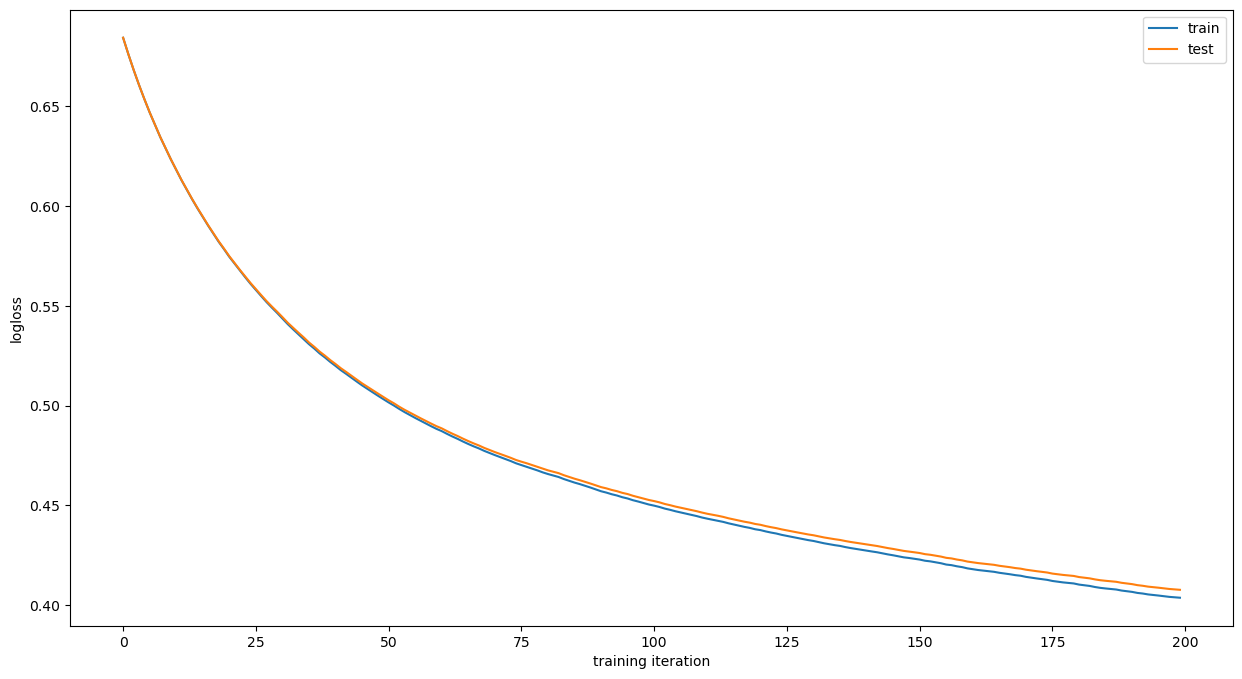

In [13]:
results = model.evals_result()
# plot learning curves
plt.plot(results['validation_0']['logloss'], label='train')
plt.plot(results['validation_1']['logloss'], label='test')
# show the legend
plt.legend()
# show the plot
plt.ylabel("logloss")
plt.xlabel("training iteration")
plt.show()

In [14]:
# import joblib
# joblib.dump(xgbclass, "bdt_all.pkl")

### Checking the classifier

Accuracy: 0.806
0.8803096957376904


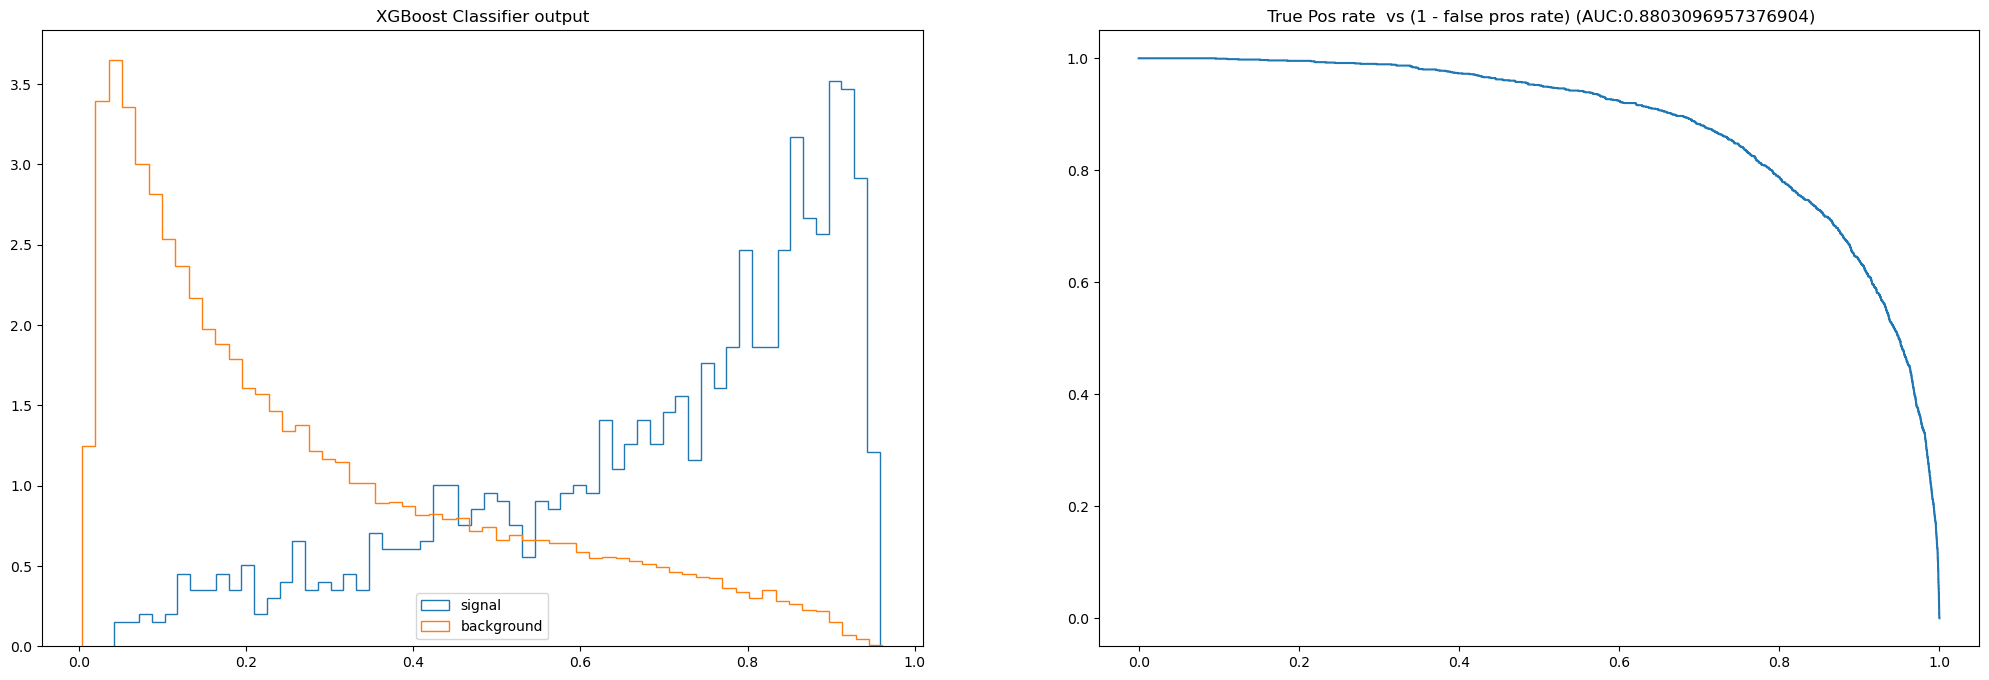

In [15]:
yscore = xgbclass.predict_proba(Xtest)
ypred = xgbclass.predict(Xtest)
accuracy = accuracy_score(ytest, ypred)
print('Accuracy: %.3f' % accuracy)

from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = xgbclass.predict_proba(Xtest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"XGBoost Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal', density=True);
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background', density=True);
ax1.legend();

In [16]:
aucs_stats = {}
aucs_stats["all vars"] = roc_auc

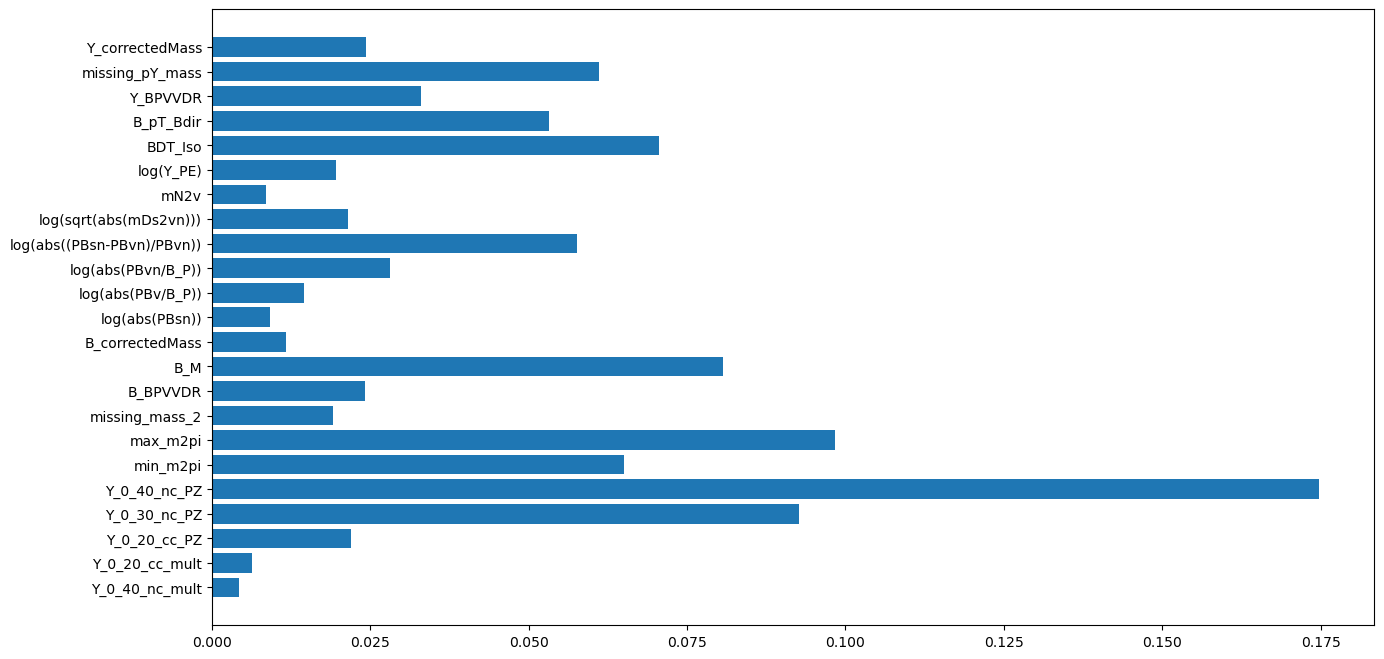

In [17]:
plt.barh(model.feature_names_in_, model.feature_importances_);

In [18]:
features_importance = dict(zip(model.feature_names_in_, model.feature_importances_))

In [19]:
{k: v for k, v in sorted(features_importance.items(), key=lambda item: item[1])}

{'Y_0_40_nc_mult': 0.004208696,
 'Y_0_20_cc_mult': 0.0063315346,
 'mN2v': 0.008522603,
 'log(abs(PBsn))': 0.009186083,
 'B_correctedMass': 0.0117133735,
 'log(abs(PBv/B_P))': 0.014545957,
 'missing_mass_2': 0.01903698,
 'log(Y_PE)': 0.019554518,
 'log(sqrt(abs(mDs2vn)))': 0.021429904,
 'Y_0_20_cc_PZ': 0.021963023,
 'B_BPVVDR': 0.0240789,
 'Y_correctedMass': 0.024353707,
 'log(abs(PBvn/B_P))': 0.028062234,
 'Y_BPVVDR': 0.033002067,
 'B_pT_Bdir': 0.053271618,
 'log(abs((PBsn-PBvn)/PBvn))': 0.05757987,
 'missing_pY_mass': 0.061059583,
 'min_m2pi': 0.06497344,
 'BDT_Iso': 0.07055056,
 'B_M': 0.080705844,
 'Y_0_30_nc_PZ': 0.09270432,
 'max_m2pi': 0.09839706,
 'Y_0_40_nc_PZ': 0.17476815}

## Trying to train without the least 2 important columns

In [20]:
train_columns_2 = [
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]

[0]	validation_0-logloss:0.68427	validation_1-logloss:0.68428
[1]	validation_0-logloss:0.67591	validation_1-logloss:0.67592
[2]	validation_0-logloss:0.66801	validation_1-logloss:0.66805
[3]	validation_0-logloss:0.66056	validation_1-logloss:0.66060
[4]	validation_0-logloss:0.65355	validation_1-logloss:0.65357
[5]	validation_0-logloss:0.64685	validation_1-logloss:0.64689
[6]	validation_0-logloss:0.64066	validation_1-logloss:0.64068
[7]	validation_0-logloss:0.63447	validation_1-logloss:0.63454
[8]	validation_0-logloss:0.62882	validation_1-logloss:0.62889
[9]	validation_0-logloss:0.62328	validation_1-logloss:0.62335
[10]	validation_0-logloss:0.61814	validation_1-logloss:0.61819
[11]	validation_0-logloss:0.61288	validation_1-logloss:0.61299
[12]	validation_0-logloss:0.60815	validation_1-logloss:0.60828
[13]	validation_0-logloss:0.60333	validation_1-logloss:0.60347
[14]	validation_0-logloss:0.59882	validation_1-logloss:0.59898
[15]	validation_0-logloss:0.59453	validation_1-logloss:0.59471
[1

[130]	validation_0-logloss:0.43220	validation_1-logloss:0.43506
[131]	validation_0-logloss:0.43161	validation_1-logloss:0.43452
[132]	validation_0-logloss:0.43104	validation_1-logloss:0.43396
[133]	validation_0-logloss:0.43056	validation_1-logloss:0.43351
[134]	validation_0-logloss:0.43010	validation_1-logloss:0.43308
[135]	validation_0-logloss:0.42970	validation_1-logloss:0.43269
[136]	validation_0-logloss:0.42912	validation_1-logloss:0.43215
[137]	validation_0-logloss:0.42863	validation_1-logloss:0.43168
[138]	validation_0-logloss:0.42819	validation_1-logloss:0.43126
[139]	validation_0-logloss:0.42775	validation_1-logloss:0.43082
[140]	validation_0-logloss:0.42737	validation_1-logloss:0.43047
[141]	validation_0-logloss:0.42692	validation_1-logloss:0.43004
[142]	validation_0-logloss:0.42632	validation_1-logloss:0.42949
[143]	validation_0-logloss:0.42579	validation_1-logloss:0.42896
[144]	validation_0-logloss:0.42527	validation_1-logloss:0.42845
[145]	validation_0-logloss:0.42483	valid

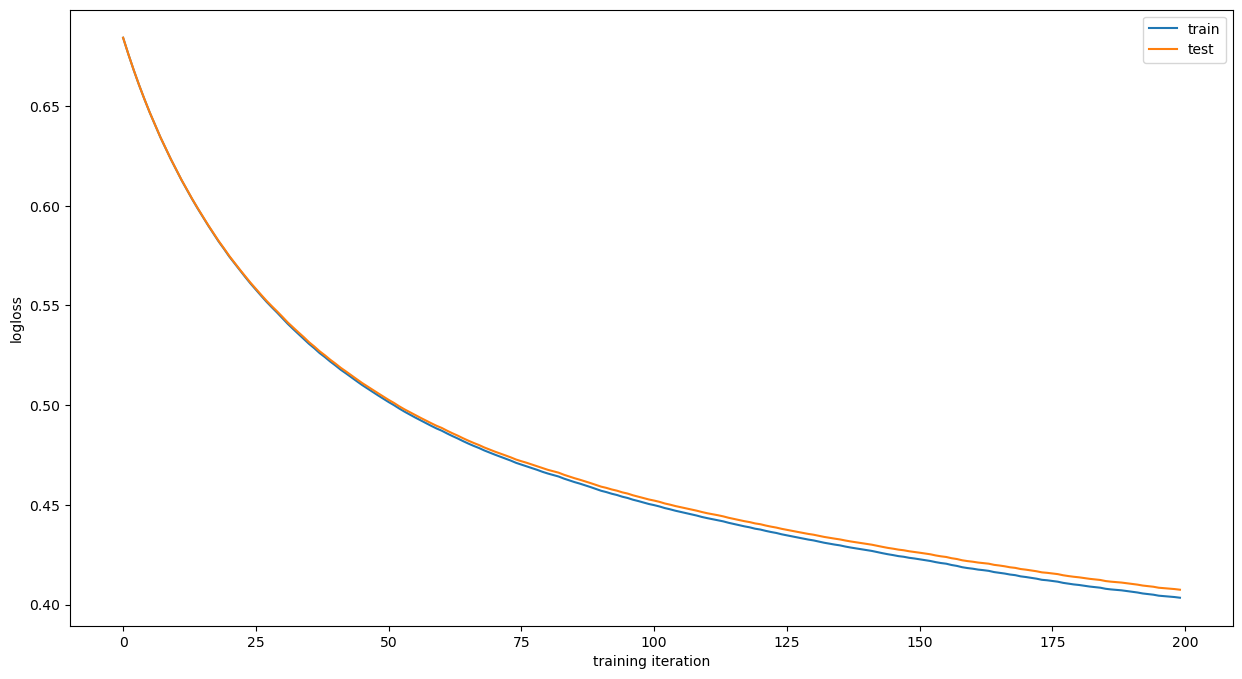

0.8806428138867151


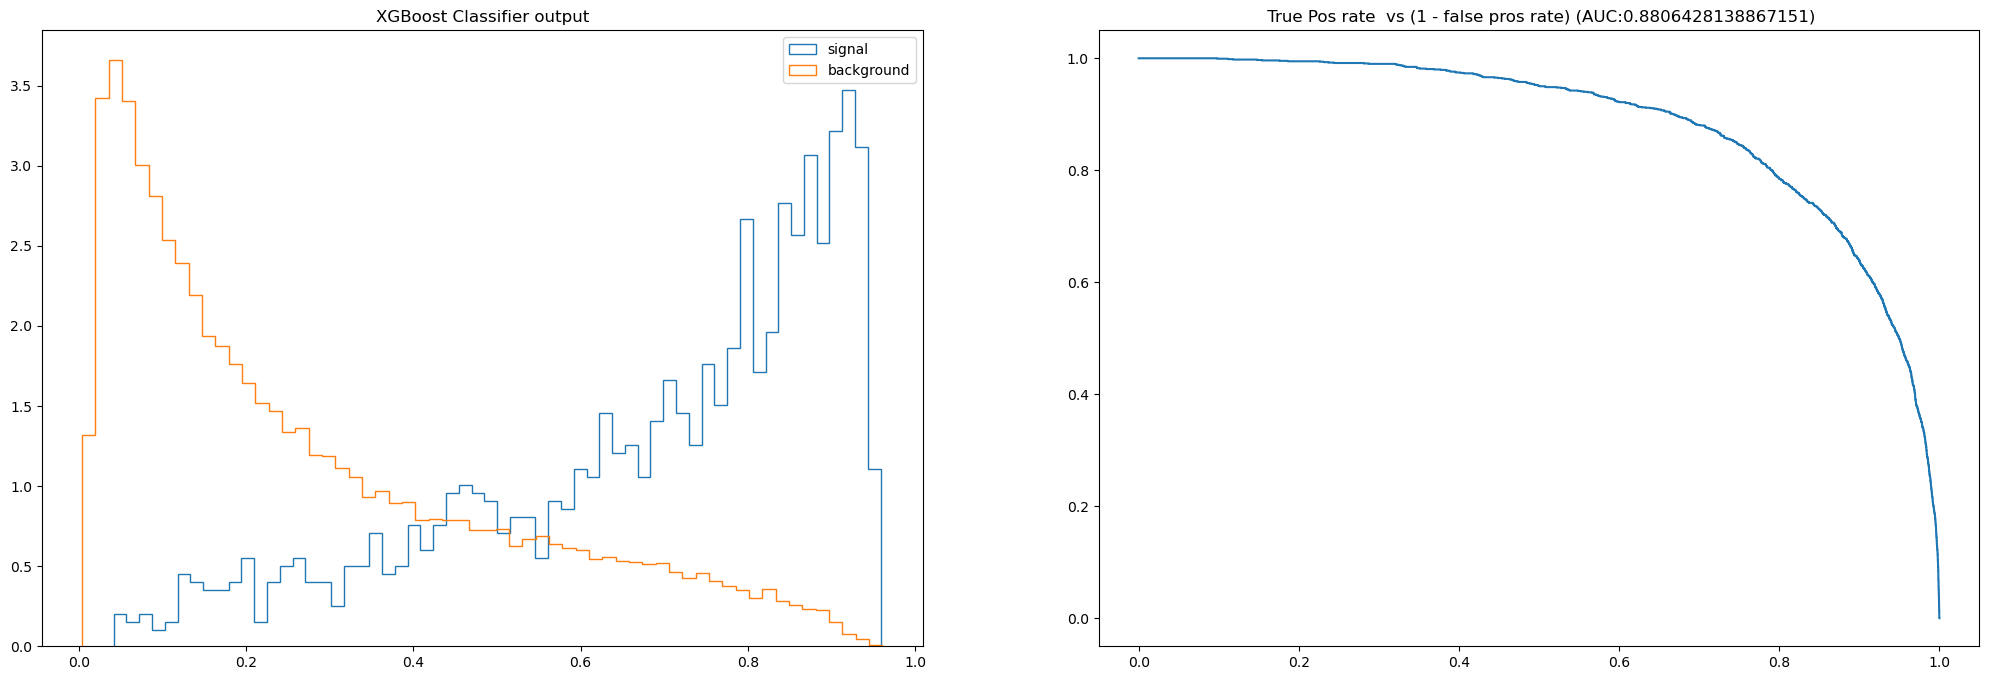

In [21]:
def train_model(train, test, train_columns):
    Xtrain = train[train_columns]
    ytrain = train["signal"]
    Xtest = test[train_columns]
    ytest = test["signal"]
    scaler = preprocessing.StandardScaler().fit(Xtrain)
    Xtrain_scaled = pd.DataFrame(scaler.transform(Xtrain), columns = Xtrain.columns)
    Xtest_scaled = pd.DataFrame(scaler.transform(Xtest), columns = Xtest.columns)
    
    # Create model and train
    ratio = len(train[train['signal']==0]) / len(train[train['signal']==1])
    
    model = xgb.XGBClassifier( eval_metric='logloss', 
                              n_estimators=200, eta=0.03, scale_pos_weight=ratio, max_depth=4)
    evalset = [(Xtrain_scaled, ytrain), (Xtest_scaled, ytest)]
    res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset)
    results = model.evals_result()
    
    # plot learning curves
    plt.plot(results['validation_0']['logloss'], label='train')
    plt.plot(results['validation_1']['logloss'], label='test')
    # show the legend
    plt.legend()
    # show the plot
    plt.ylabel("logloss")
    plt.xlabel("training iteration")
    plt.show()

    
    # Now check the model
    yscore = model.predict_proba(Xtest_scaled)
    ypred = model.predict(Xtest_scaled)
    accuracy = accuracy_score(ytest, ypred)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

    # ROC curve 
    fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
    roc_auc = auc(fpr, tpr)
    ax2.plot(1 - fpr, tpr)
    ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
    print(roc_auc)

    # Classifier output
    ax1.set_title(f"XGBoost Classifier output")
    t = 'step'
    n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal', density=True);
    ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background', density=True);
    ax1.legend()
    return model, roc_auc
    
    
model2, auc2 = train_model(train, test, train_columns_2)
aucs_stats["without mult"] = auc2

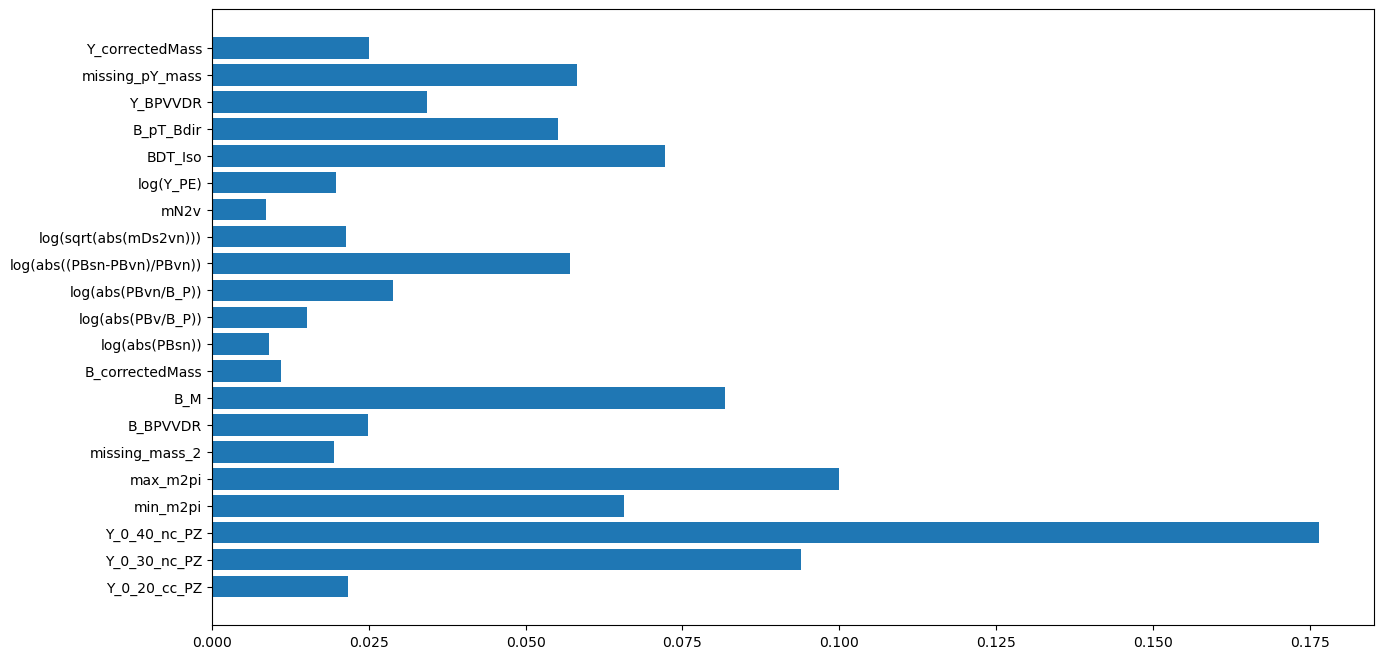

In [22]:
plt.barh(model2.feature_names_in_, model2.feature_importances_);

In [23]:
aucs_stats


{'all vars': 0.8803096957376904, 'without mult': 0.8806428138867151}

## Removing the mN2V column too

[0]	validation_0-logloss:0.68427	validation_1-logloss:0.68428
[1]	validation_0-logloss:0.67591	validation_1-logloss:0.67592
[2]	validation_0-logloss:0.66801	validation_1-logloss:0.66805
[3]	validation_0-logloss:0.66056	validation_1-logloss:0.66060
[4]	validation_0-logloss:0.65355	validation_1-logloss:0.65357
[5]	validation_0-logloss:0.64685	validation_1-logloss:0.64689
[6]	validation_0-logloss:0.64066	validation_1-logloss:0.64068
[7]	validation_0-logloss:0.63447	validation_1-logloss:0.63454
[8]	validation_0-logloss:0.62882	validation_1-logloss:0.62889
[9]	validation_0-logloss:0.62328	validation_1-logloss:0.62335
[10]	validation_0-logloss:0.61814	validation_1-logloss:0.61819
[11]	validation_0-logloss:0.61288	validation_1-logloss:0.61299
[12]	validation_0-logloss:0.60815	validation_1-logloss:0.60828
[13]	validation_0-logloss:0.60333	validation_1-logloss:0.60347
[14]	validation_0-logloss:0.59882	validation_1-logloss:0.59898
[15]	validation_0-logloss:0.59453	validation_1-logloss:0.59471
[1

[130]	validation_0-logloss:0.43212	validation_1-logloss:0.43499
[131]	validation_0-logloss:0.43167	validation_1-logloss:0.43455
[132]	validation_0-logloss:0.43114	validation_1-logloss:0.43405
[133]	validation_0-logloss:0.43076	validation_1-logloss:0.43371
[134]	validation_0-logloss:0.43035	validation_1-logloss:0.43332
[135]	validation_0-logloss:0.42980	validation_1-logloss:0.43279
[136]	validation_0-logloss:0.42923	validation_1-logloss:0.43222
[137]	validation_0-logloss:0.42877	validation_1-logloss:0.43177
[138]	validation_0-logloss:0.42831	validation_1-logloss:0.43133
[139]	validation_0-logloss:0.42752	validation_1-logloss:0.43058
[140]	validation_0-logloss:0.42695	validation_1-logloss:0.43002
[141]	validation_0-logloss:0.42653	validation_1-logloss:0.42962
[142]	validation_0-logloss:0.42601	validation_1-logloss:0.42914
[143]	validation_0-logloss:0.42564	validation_1-logloss:0.42877
[144]	validation_0-logloss:0.42503	validation_1-logloss:0.42820
[145]	validation_0-logloss:0.42454	valid

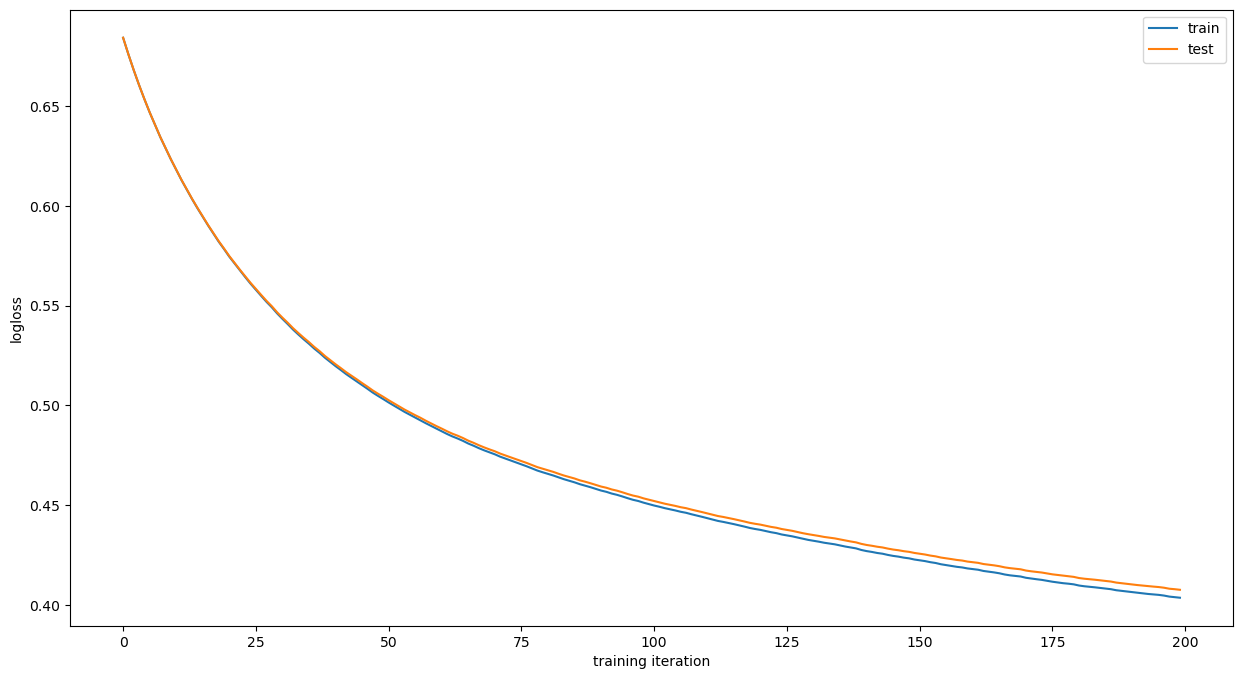

0.8806580790364531


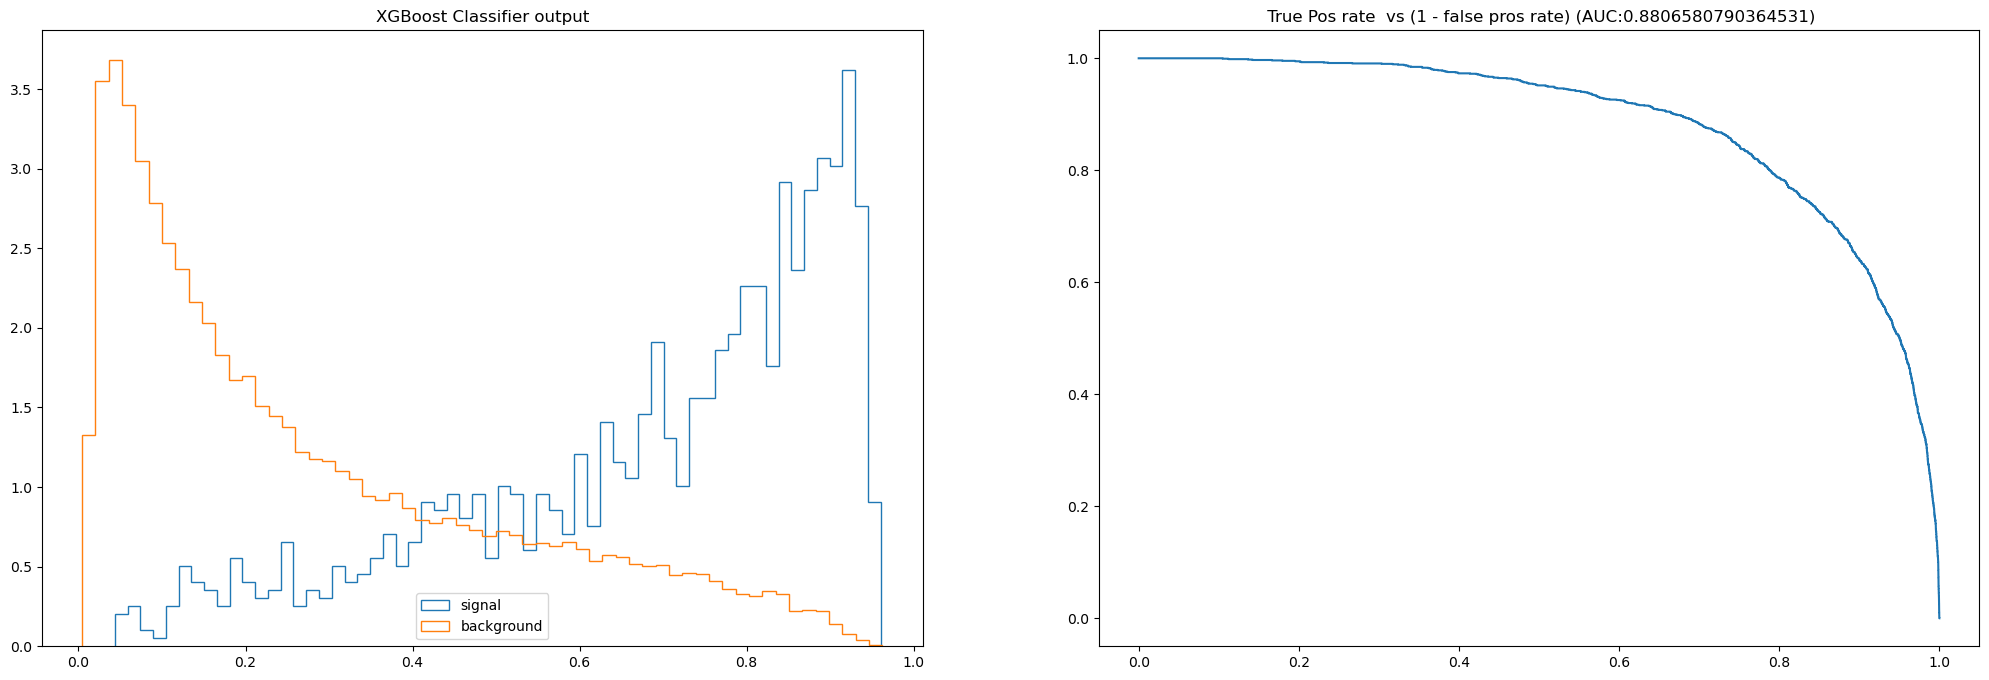

In [24]:
train_columns_3 = [
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]
model3, auc3 = train_model(train, test, train_columns_3)
aucs_stats["without mult & mN2V"] = auc3

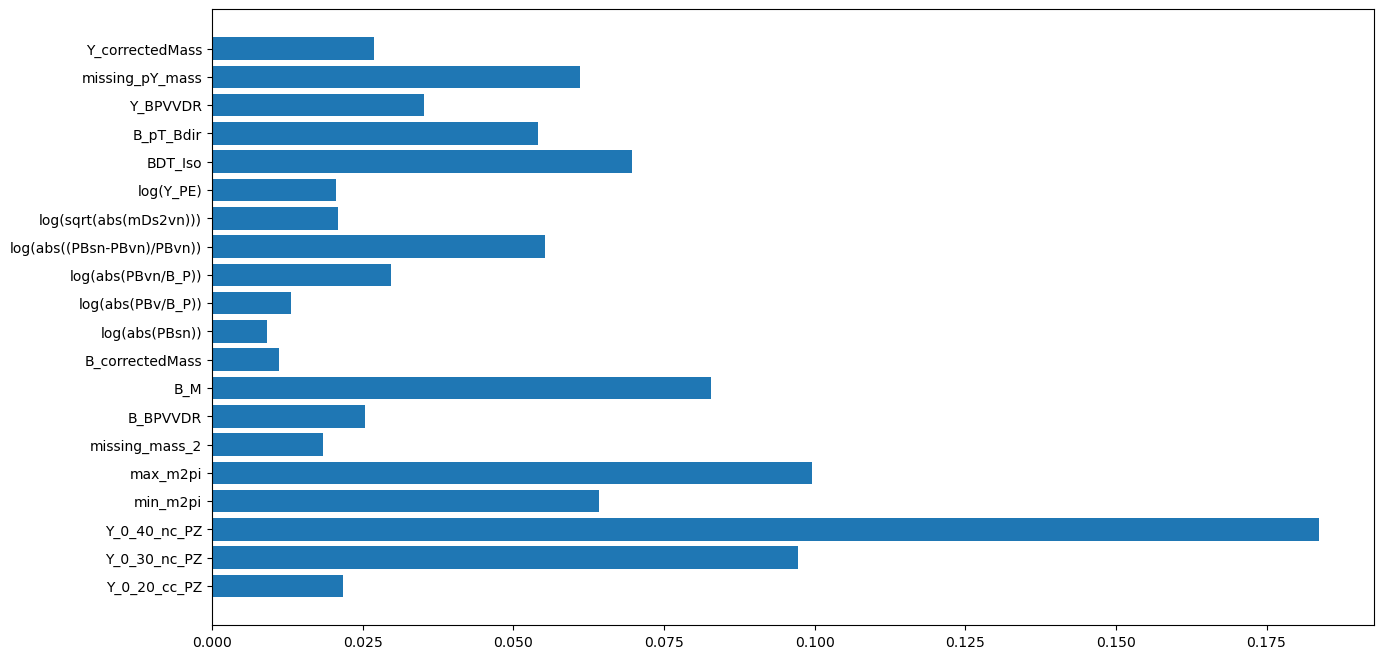

In [25]:
plt.barh(model3.feature_names_in_, model3.feature_importances_);

## Removing log(abs(PBsn)) and correctedMass

[0]	validation_0-logloss:0.68427	validation_1-logloss:0.68428
[1]	validation_0-logloss:0.67591	validation_1-logloss:0.67592
[2]	validation_0-logloss:0.66801	validation_1-logloss:0.66805
[3]	validation_0-logloss:0.66056	validation_1-logloss:0.66060
[4]	validation_0-logloss:0.65355	validation_1-logloss:0.65357
[5]	validation_0-logloss:0.64685	validation_1-logloss:0.64689
[6]	validation_0-logloss:0.64066	validation_1-logloss:0.64068
[7]	validation_0-logloss:0.63447	validation_1-logloss:0.63454
[8]	validation_0-logloss:0.62882	validation_1-logloss:0.62889
[9]	validation_0-logloss:0.62328	validation_1-logloss:0.62335
[10]	validation_0-logloss:0.61814	validation_1-logloss:0.61819
[11]	validation_0-logloss:0.61288	validation_1-logloss:0.61299
[12]	validation_0-logloss:0.60815	validation_1-logloss:0.60828
[13]	validation_0-logloss:0.60333	validation_1-logloss:0.60347
[14]	validation_0-logloss:0.59882	validation_1-logloss:0.59898
[15]	validation_0-logloss:0.59453	validation_1-logloss:0.59471
[1

[130]	validation_0-logloss:0.43228	validation_1-logloss:0.43515
[131]	validation_0-logloss:0.43176	validation_1-logloss:0.43467
[132]	validation_0-logloss:0.43129	validation_1-logloss:0.43420
[133]	validation_0-logloss:0.43077	validation_1-logloss:0.43371
[134]	validation_0-logloss:0.43018	validation_1-logloss:0.43315
[135]	validation_0-logloss:0.42963	validation_1-logloss:0.43264
[136]	validation_0-logloss:0.42922	validation_1-logloss:0.43223
[137]	validation_0-logloss:0.42872	validation_1-logloss:0.43176
[138]	validation_0-logloss:0.42833	validation_1-logloss:0.43138
[139]	validation_0-logloss:0.42776	validation_1-logloss:0.43086
[140]	validation_0-logloss:0.42729	validation_1-logloss:0.43041
[141]	validation_0-logloss:0.42682	validation_1-logloss:0.42997
[142]	validation_0-logloss:0.42640	validation_1-logloss:0.42954
[143]	validation_0-logloss:0.42579	validation_1-logloss:0.42894
[144]	validation_0-logloss:0.42527	validation_1-logloss:0.42842
[145]	validation_0-logloss:0.42468	valid

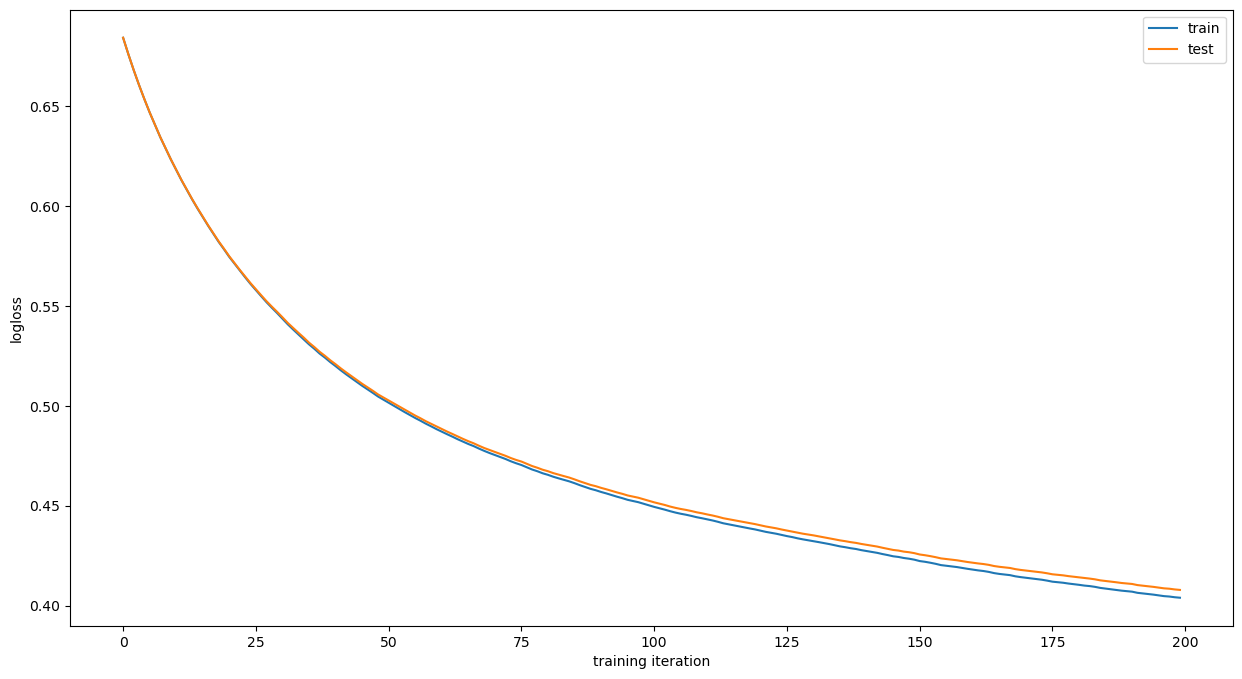

0.8804740163258183


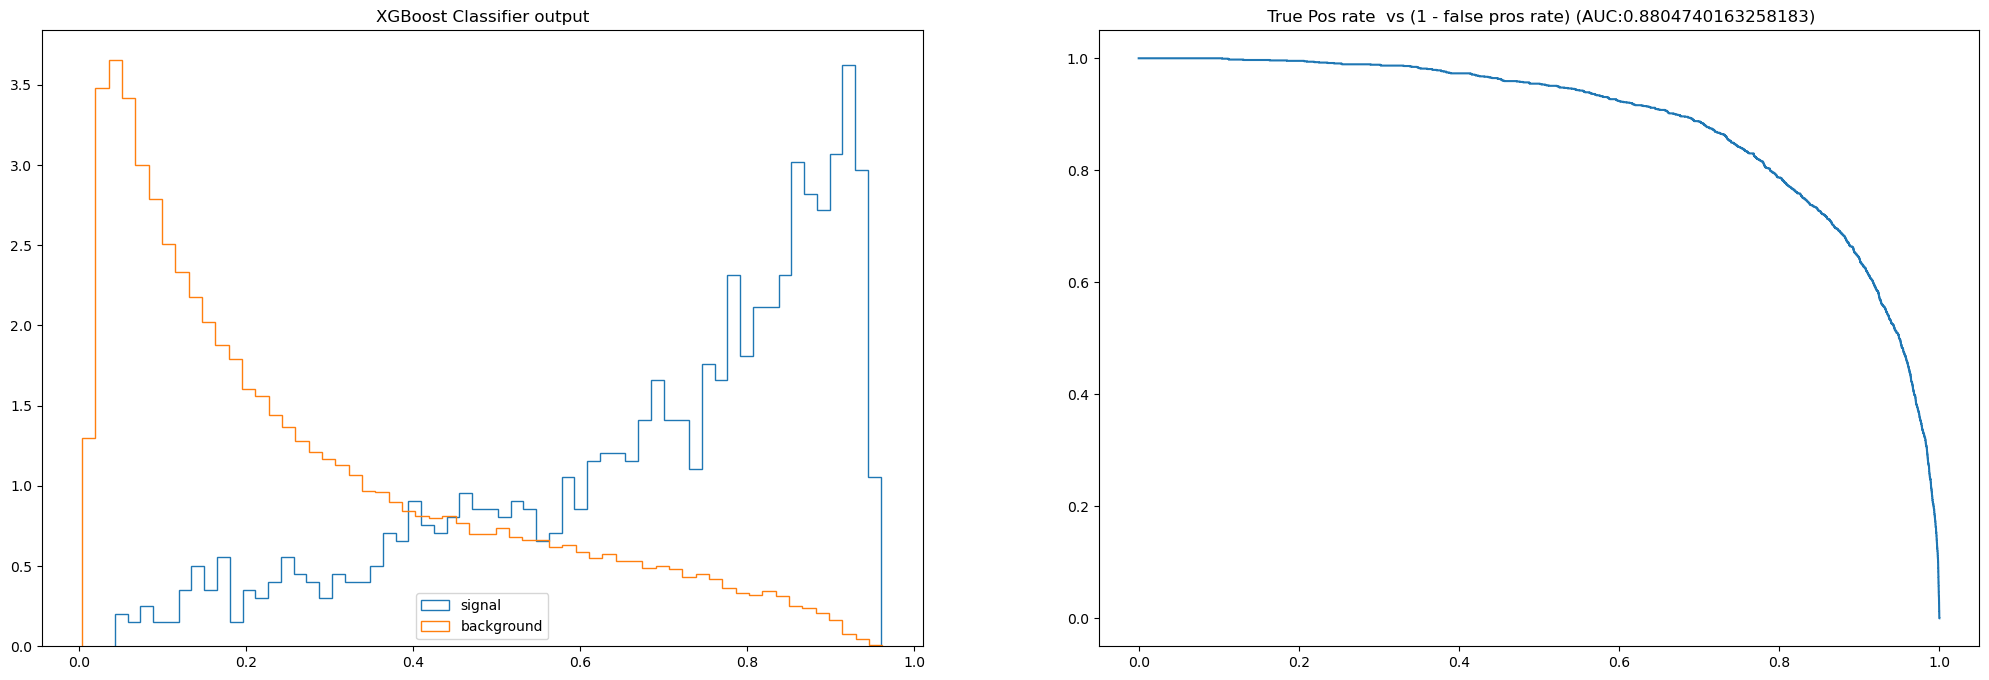

In [32]:
train_columns_4 = [
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]
model4, auc4 = train_model(train, test, train_columns_4)
aucs_stats["without correctedMass"] = auc4

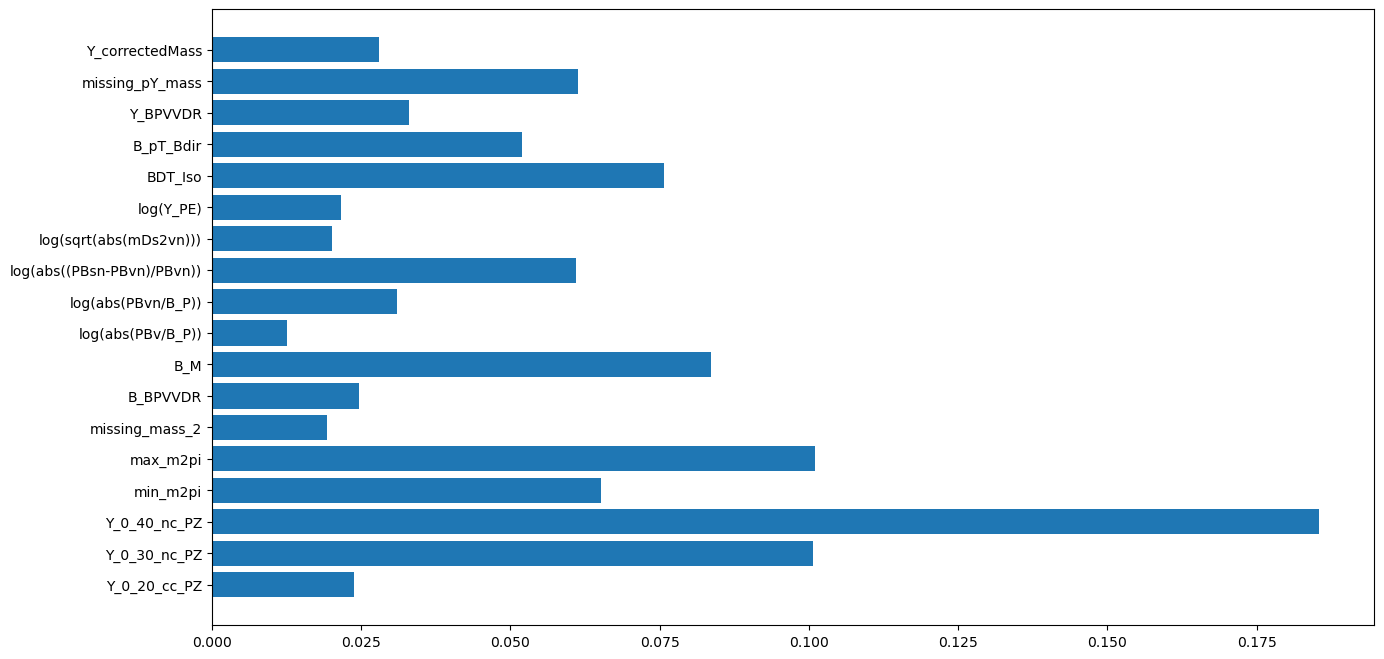

In [39]:
plt.barh(model4.feature_names_in_, model4.feature_importances_);

## Without  log(abs(PBv/B_P)) and missing_mass_2


[0]	validation_0-logloss:0.68427	validation_1-logloss:0.68428
[1]	validation_0-logloss:0.67591	validation_1-logloss:0.67592
[2]	validation_0-logloss:0.66801	validation_1-logloss:0.66805
[3]	validation_0-logloss:0.66056	validation_1-logloss:0.66060
[4]	validation_0-logloss:0.65355	validation_1-logloss:0.65357
[5]	validation_0-logloss:0.64686	validation_1-logloss:0.64691
[6]	validation_0-logloss:0.64068	validation_1-logloss:0.64072
[7]	validation_0-logloss:0.63451	validation_1-logloss:0.63459
[8]	validation_0-logloss:0.62886	validation_1-logloss:0.62894
[9]	validation_0-logloss:0.62332	validation_1-logloss:0.62341
[10]	validation_0-logloss:0.61822	validation_1-logloss:0.61829
[11]	validation_0-logloss:0.61299	validation_1-logloss:0.61311
[12]	validation_0-logloss:0.60823	validation_1-logloss:0.60838
[13]	validation_0-logloss:0.60342	validation_1-logloss:0.60359
[14]	validation_0-logloss:0.59892	validation_1-logloss:0.59911
[15]	validation_0-logloss:0.59463	validation_1-logloss:0.59485
[1

[130]	validation_0-logloss:0.43297	validation_1-logloss:0.43590
[131]	validation_0-logloss:0.43250	validation_1-logloss:0.43545
[132]	validation_0-logloss:0.43206	validation_1-logloss:0.43501
[133]	validation_0-logloss:0.43160	validation_1-logloss:0.43458
[134]	validation_0-logloss:0.43105	validation_1-logloss:0.43404
[135]	validation_0-logloss:0.43054	validation_1-logloss:0.43357
[136]	validation_0-logloss:0.43012	validation_1-logloss:0.43317
[137]	validation_0-logloss:0.42966	validation_1-logloss:0.43272
[138]	validation_0-logloss:0.42904	validation_1-logloss:0.43211
[139]	validation_0-logloss:0.42858	validation_1-logloss:0.43166
[140]	validation_0-logloss:0.42808	validation_1-logloss:0.43119
[141]	validation_0-logloss:0.42767	validation_1-logloss:0.43080
[142]	validation_0-logloss:0.42732	validation_1-logloss:0.43045
[143]	validation_0-logloss:0.42659	validation_1-logloss:0.42976
[144]	validation_0-logloss:0.42617	validation_1-logloss:0.42934
[145]	validation_0-logloss:0.42583	valid

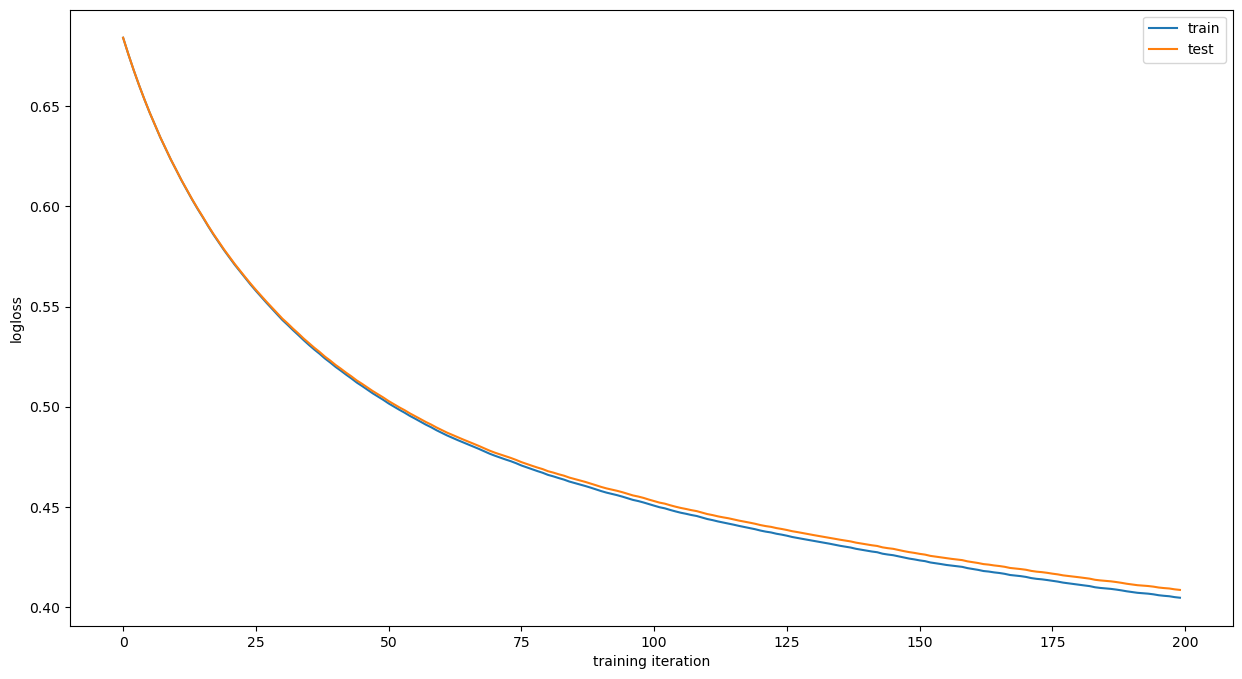

0.8803189634333414


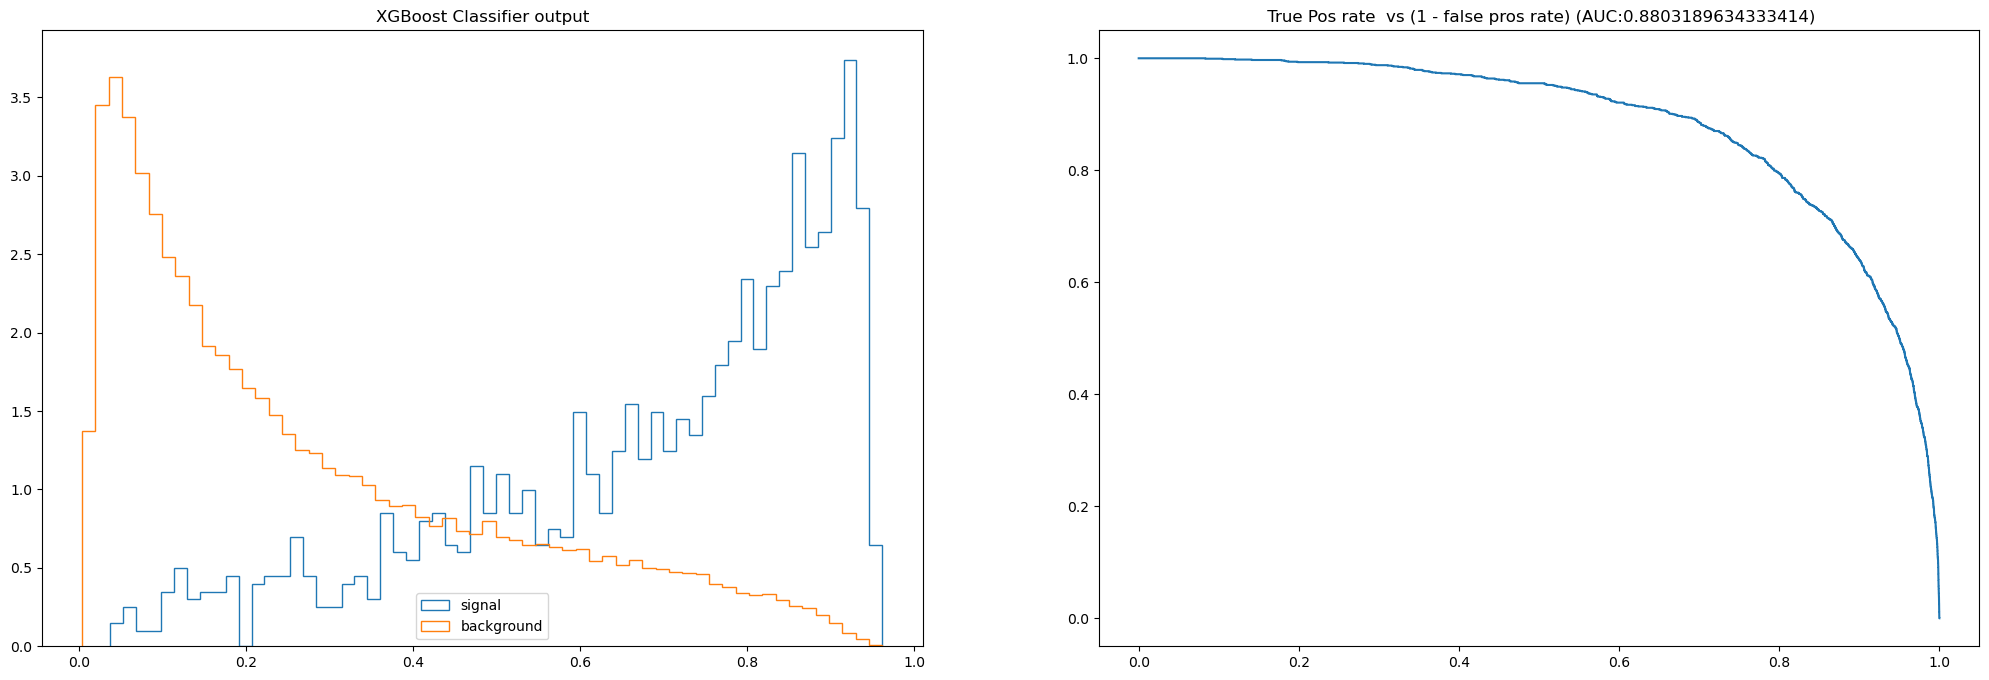

In [40]:
train_columns_5 = [
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "B_BPVVDR",
    "B_M",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]
model5, auc5 = train_model(train, test, train_columns_5)
aucs_stats["without missing_mass_2"] = auc5

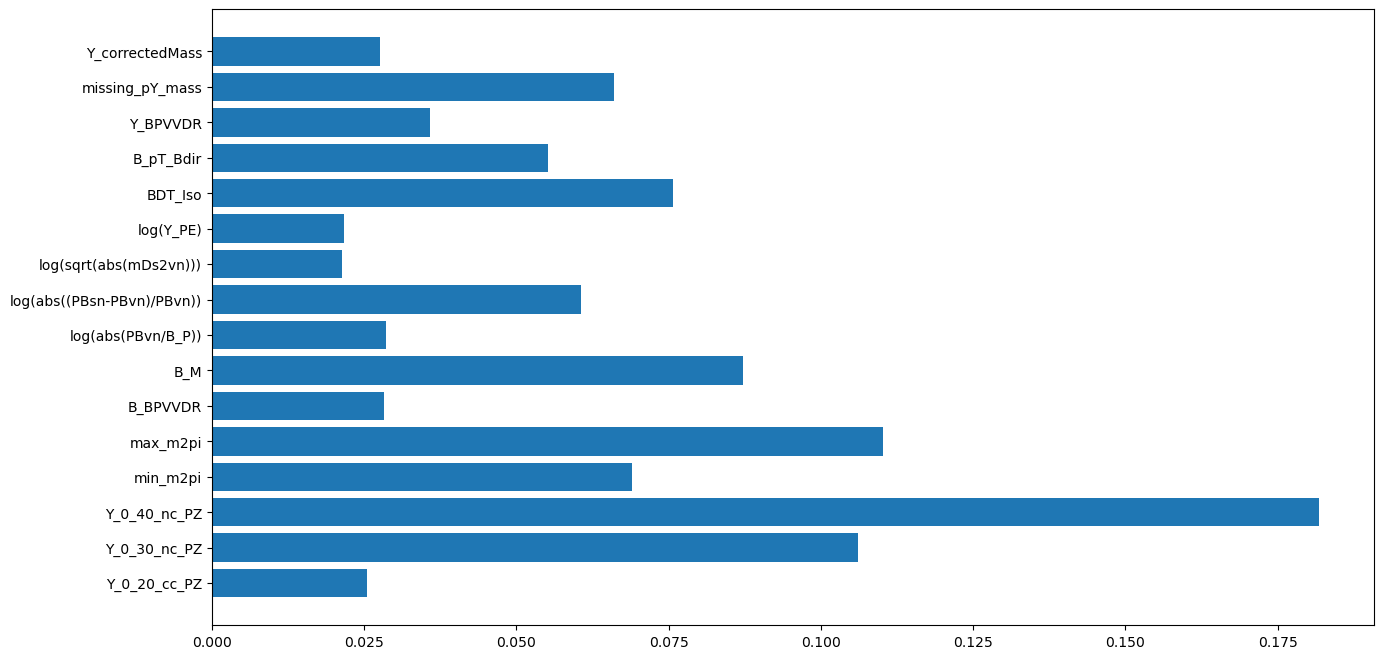

In [41]:
plt.barh(model5.feature_names_in_, model5.feature_importances_);

## Without log(sqrt(abs(mDs2vn))) and log(Y_PE)
   

[0]	validation_0-logloss:0.68427	validation_1-logloss:0.68428
[1]	validation_0-logloss:0.67591	validation_1-logloss:0.67593
[2]	validation_0-logloss:0.66801	validation_1-logloss:0.66806
[3]	validation_0-logloss:0.66057	validation_1-logloss:0.66061
[4]	validation_0-logloss:0.65355	validation_1-logloss:0.65359
[5]	validation_0-logloss:0.64687	validation_1-logloss:0.64693
[6]	validation_0-logloss:0.64069	validation_1-logloss:0.64073
[7]	validation_0-logloss:0.63451	validation_1-logloss:0.63460
[8]	validation_0-logloss:0.62887	validation_1-logloss:0.62896
[9]	validation_0-logloss:0.62333	validation_1-logloss:0.62343
[10]	validation_0-logloss:0.61824	validation_1-logloss:0.61832
[11]	validation_0-logloss:0.61300	validation_1-logloss:0.61314
[12]	validation_0-logloss:0.60826	validation_1-logloss:0.60842
[13]	validation_0-logloss:0.60345	validation_1-logloss:0.60363
[14]	validation_0-logloss:0.59895	validation_1-logloss:0.59916
[15]	validation_0-logloss:0.59467	validation_1-logloss:0.59489
[1

[130]	validation_0-logloss:0.43322	validation_1-logloss:0.43627
[131]	validation_0-logloss:0.43265	validation_1-logloss:0.43570
[132]	validation_0-logloss:0.43222	validation_1-logloss:0.43526
[133]	validation_0-logloss:0.43167	validation_1-logloss:0.43474
[134]	validation_0-logloss:0.43091	validation_1-logloss:0.43402
[135]	validation_0-logloss:0.43049	validation_1-logloss:0.43361
[136]	validation_0-logloss:0.42988	validation_1-logloss:0.43306
[137]	validation_0-logloss:0.42938	validation_1-logloss:0.43258
[138]	validation_0-logloss:0.42897	validation_1-logloss:0.43219
[139]	validation_0-logloss:0.42853	validation_1-logloss:0.43177
[140]	validation_0-logloss:0.42821	validation_1-logloss:0.43146
[141]	validation_0-logloss:0.42775	validation_1-logloss:0.43102
[142]	validation_0-logloss:0.42723	validation_1-logloss:0.43054
[143]	validation_0-logloss:0.42668	validation_1-logloss:0.43002
[144]	validation_0-logloss:0.42630	validation_1-logloss:0.42966
[145]	validation_0-logloss:0.42589	valid

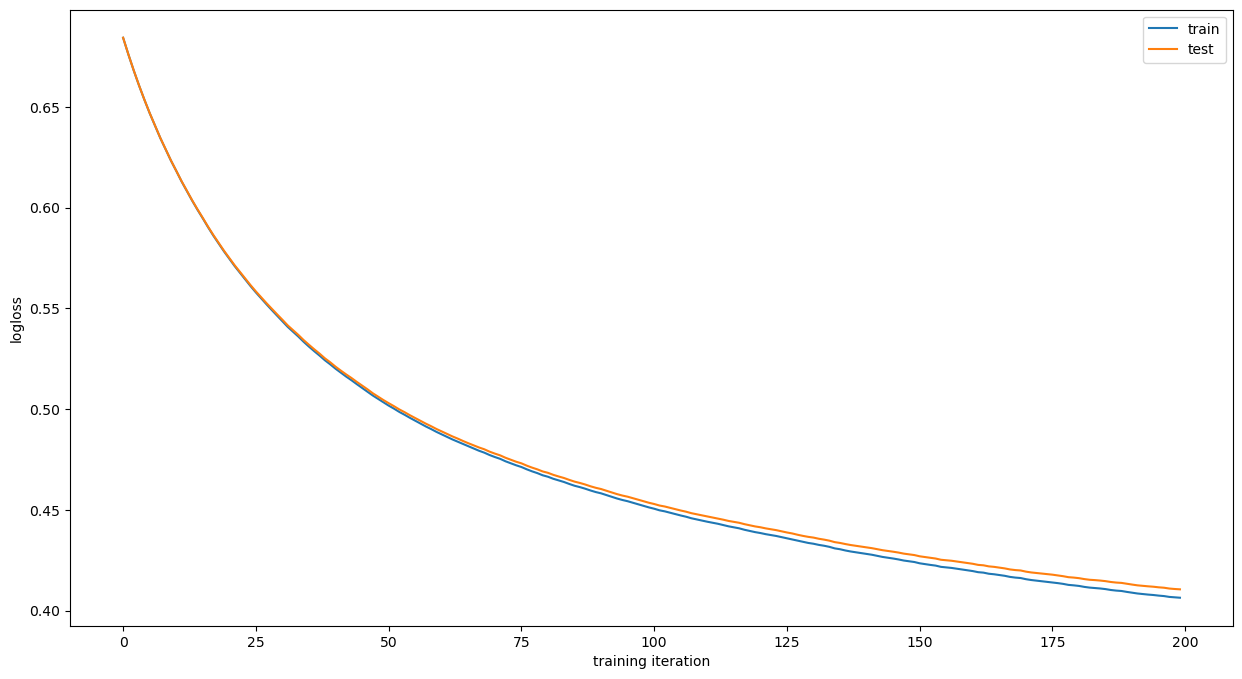

0.878653179611224


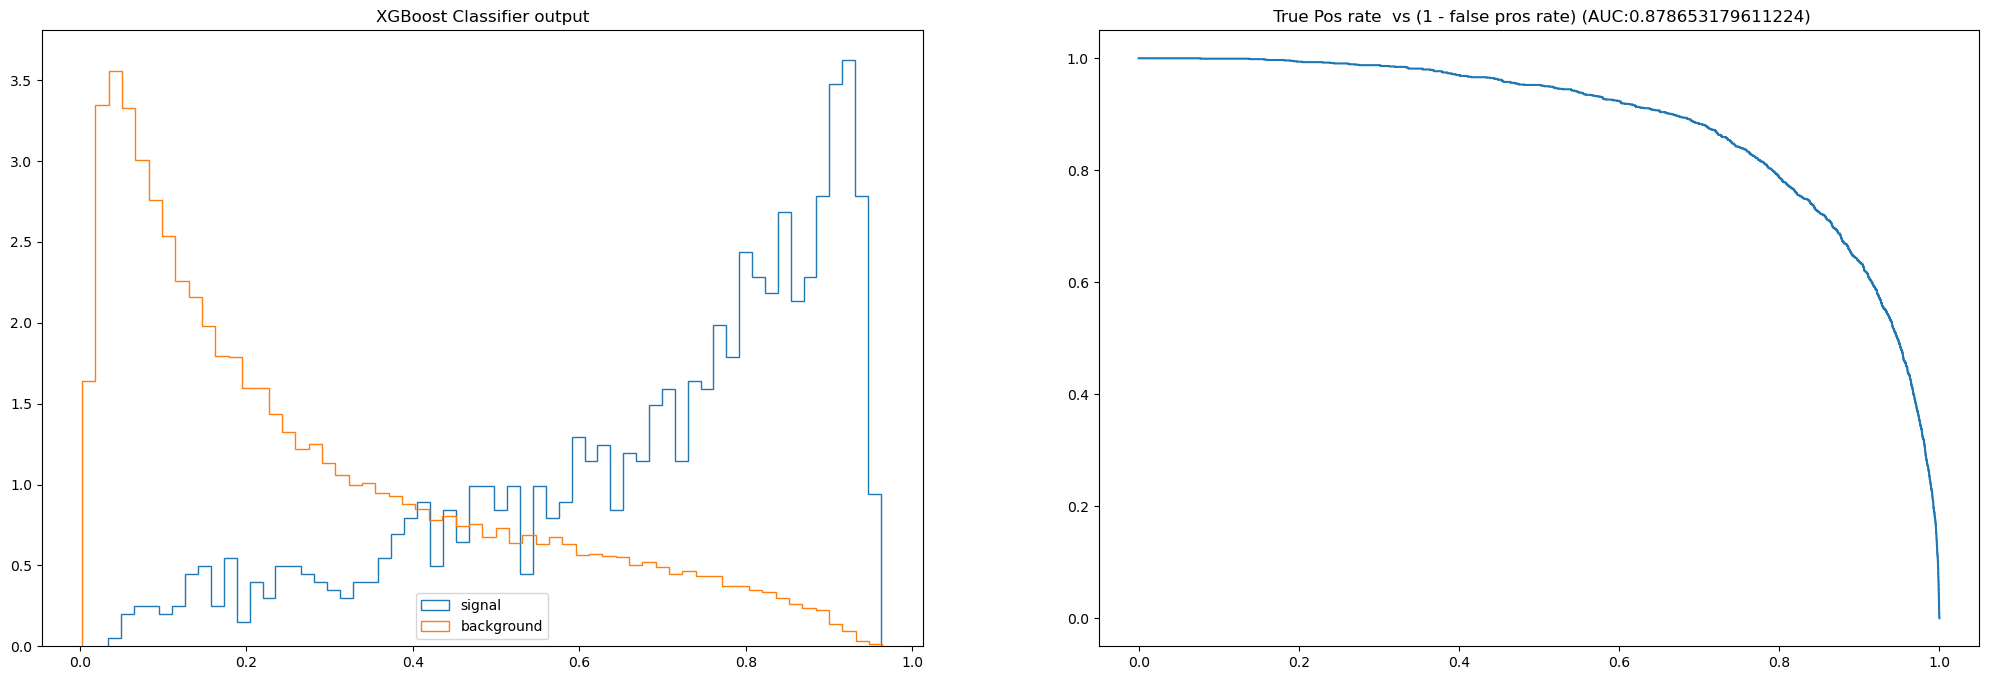

In [45]:
train_columns_6 = [
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "B_BPVVDR",
    "B_M",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]
model6, auc6 = train_model(train, test, train_columns_6)
aucs_stats["without log(Y_PE)"] = auc6

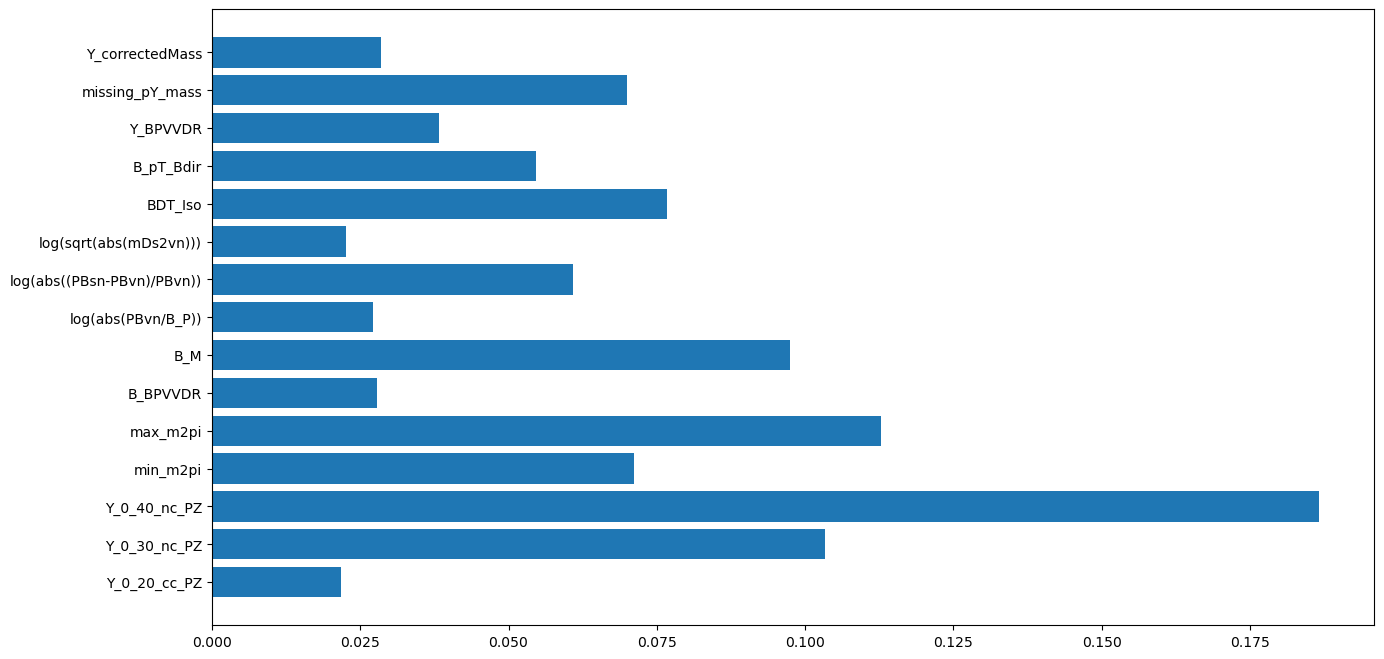

In [48]:
plt.barh(model6.feature_names_in_, model6.feature_importances_);

## Without log(abs(PBvn/B_P)), log(sqrt(abs(mDs2vn))) and Y_0_20_cc_PZ

[0]	validation_0-logloss:0.68427	validation_1-logloss:0.68428
[1]	validation_0-logloss:0.67591	validation_1-logloss:0.67593
[2]	validation_0-logloss:0.66801	validation_1-logloss:0.66806
[3]	validation_0-logloss:0.66057	validation_1-logloss:0.66061
[4]	validation_0-logloss:0.65355	validation_1-logloss:0.65359
[5]	validation_0-logloss:0.64687	validation_1-logloss:0.64693
[6]	validation_0-logloss:0.64070	validation_1-logloss:0.64075
[7]	validation_0-logloss:0.63453	validation_1-logloss:0.63462
[8]	validation_0-logloss:0.62889	validation_1-logloss:0.62900
[9]	validation_0-logloss:0.62335	validation_1-logloss:0.62347
[10]	validation_0-logloss:0.61825	validation_1-logloss:0.61840
[11]	validation_0-logloss:0.61304	validation_1-logloss:0.61325
[12]	validation_0-logloss:0.60819	validation_1-logloss:0.60845
[13]	validation_0-logloss:0.60338	validation_1-logloss:0.60365
[14]	validation_0-logloss:0.59904	validation_1-logloss:0.59933
[15]	validation_0-logloss:0.59476	validation_1-logloss:0.59506
[1

[130]	validation_0-logloss:0.43639	validation_1-logloss:0.43938
[131]	validation_0-logloss:0.43584	validation_1-logloss:0.43885
[132]	validation_0-logloss:0.43543	validation_1-logloss:0.43848
[133]	validation_0-logloss:0.43497	validation_1-logloss:0.43802
[134]	validation_0-logloss:0.43451	validation_1-logloss:0.43759
[135]	validation_0-logloss:0.43398	validation_1-logloss:0.43705
[136]	validation_0-logloss:0.43355	validation_1-logloss:0.43666
[137]	validation_0-logloss:0.43311	validation_1-logloss:0.43621
[138]	validation_0-logloss:0.43268	validation_1-logloss:0.43581
[139]	validation_0-logloss:0.43226	validation_1-logloss:0.43540
[140]	validation_0-logloss:0.43199	validation_1-logloss:0.43515
[141]	validation_0-logloss:0.43158	validation_1-logloss:0.43476
[142]	validation_0-logloss:0.43112	validation_1-logloss:0.43431
[143]	validation_0-logloss:0.43063	validation_1-logloss:0.43381
[144]	validation_0-logloss:0.43023	validation_1-logloss:0.43344
[145]	validation_0-logloss:0.42984	valid

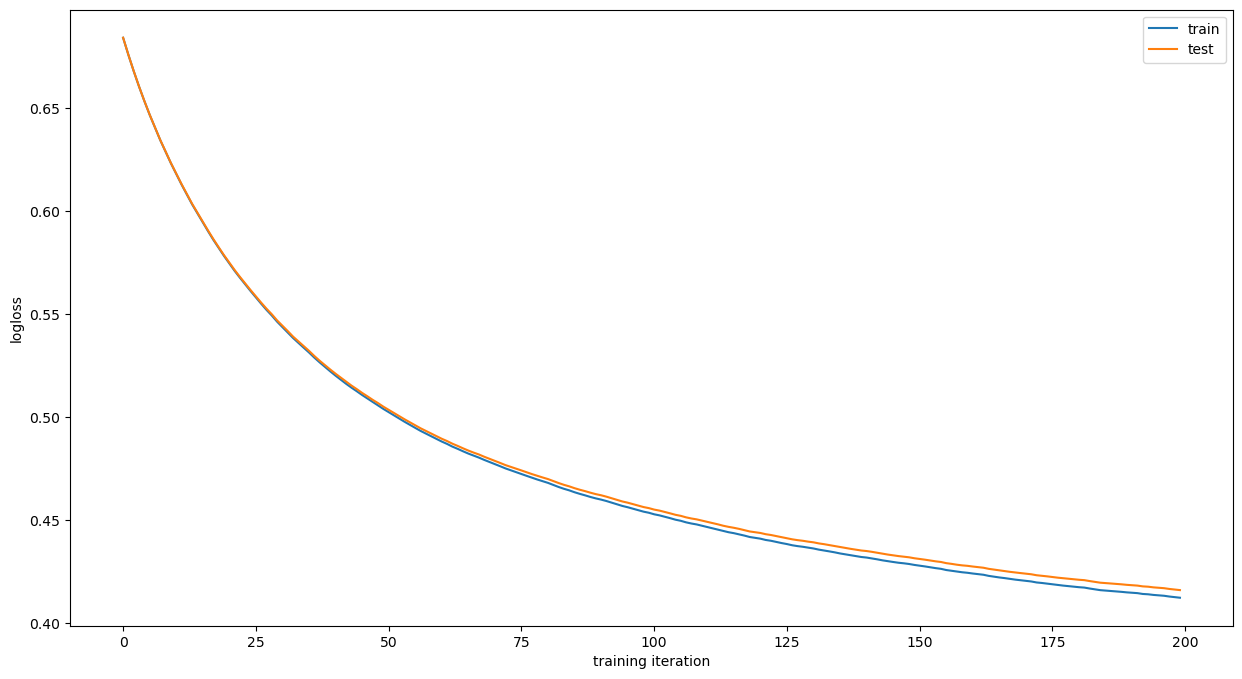

0.8746715579343929


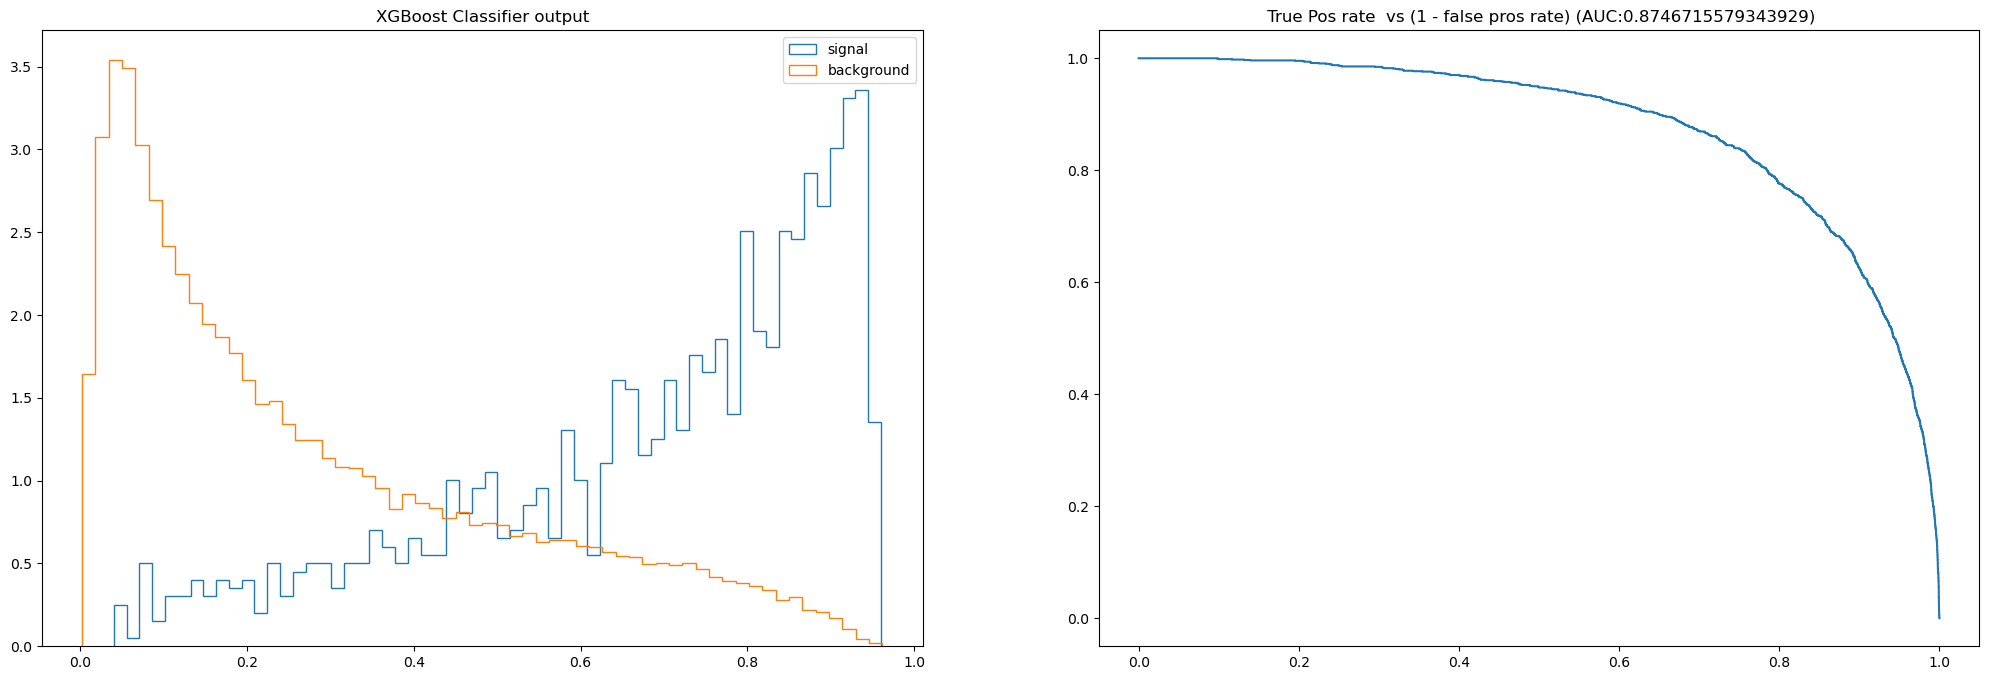

In [49]:
train_columns_7 = [
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "B_BPVVDR",
    "B_M",
    "log(abs((PBsn-PBvn)/PBvn))",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]
model7, auc7 = train_model(train, test, train_columns_7)
aucs_stats["without Y_0_20_cc_PZ"] = auc7

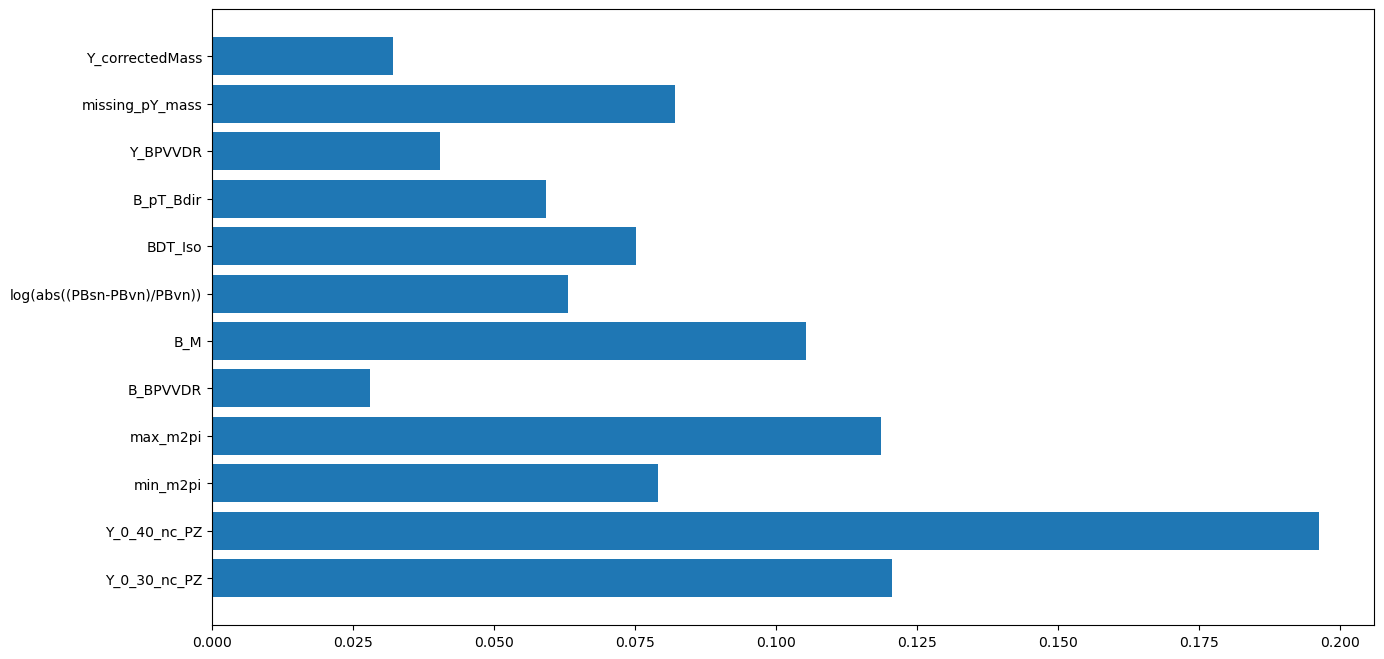

In [51]:
plt.barh(model7.feature_names_in_, model7.feature_importances_);

## Without B_BPVVDR

[0]	validation_0-logloss:0.68427	validation_1-logloss:0.68428
[1]	validation_0-logloss:0.67591	validation_1-logloss:0.67593
[2]	validation_0-logloss:0.66801	validation_1-logloss:0.66806
[3]	validation_0-logloss:0.66057	validation_1-logloss:0.66061
[4]	validation_0-logloss:0.65355	validation_1-logloss:0.65359
[5]	validation_0-logloss:0.64687	validation_1-logloss:0.64693
[6]	validation_0-logloss:0.64070	validation_1-logloss:0.64075
[7]	validation_0-logloss:0.63453	validation_1-logloss:0.63462
[8]	validation_0-logloss:0.62889	validation_1-logloss:0.62900
[9]	validation_0-logloss:0.62335	validation_1-logloss:0.62347
[10]	validation_0-logloss:0.61825	validation_1-logloss:0.61840
[11]	validation_0-logloss:0.61304	validation_1-logloss:0.61325
[12]	validation_0-logloss:0.60819	validation_1-logloss:0.60845
[13]	validation_0-logloss:0.60338	validation_1-logloss:0.60365
[14]	validation_0-logloss:0.59904	validation_1-logloss:0.59933
[15]	validation_0-logloss:0.59476	validation_1-logloss:0.59506
[1

[130]	validation_0-logloss:0.44089	validation_1-logloss:0.44355
[131]	validation_0-logloss:0.44053	validation_1-logloss:0.44319
[132]	validation_0-logloss:0.44012	validation_1-logloss:0.44281
[133]	validation_0-logloss:0.43981	validation_1-logloss:0.44252
[134]	validation_0-logloss:0.43949	validation_1-logloss:0.44219
[135]	validation_0-logloss:0.43908	validation_1-logloss:0.44182
[136]	validation_0-logloss:0.43881	validation_1-logloss:0.44154
[137]	validation_0-logloss:0.43839	validation_1-logloss:0.44115
[138]	validation_0-logloss:0.43810	validation_1-logloss:0.44088
[139]	validation_0-logloss:0.43774	validation_1-logloss:0.44053
[140]	validation_0-logloss:0.43740	validation_1-logloss:0.44022
[141]	validation_0-logloss:0.43706	validation_1-logloss:0.43988
[142]	validation_0-logloss:0.43667	validation_1-logloss:0.43949
[143]	validation_0-logloss:0.43636	validation_1-logloss:0.43922
[144]	validation_0-logloss:0.43613	validation_1-logloss:0.43900
[145]	validation_0-logloss:0.43590	valid

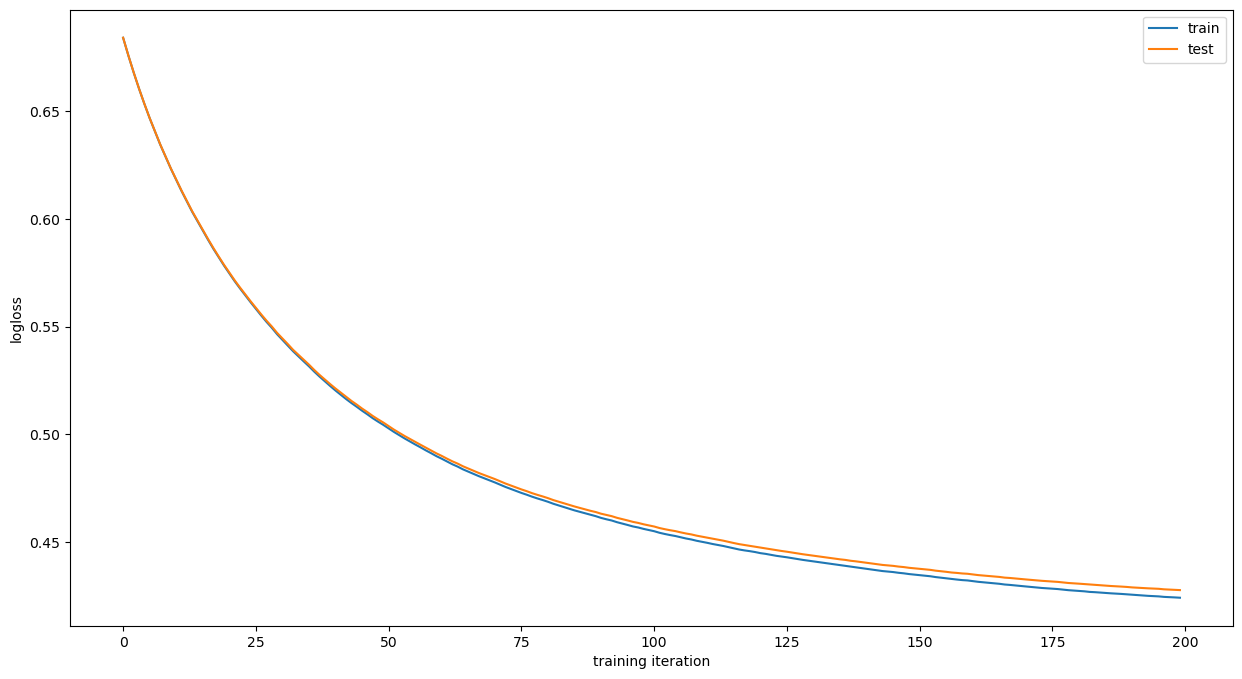

0.866629442629199


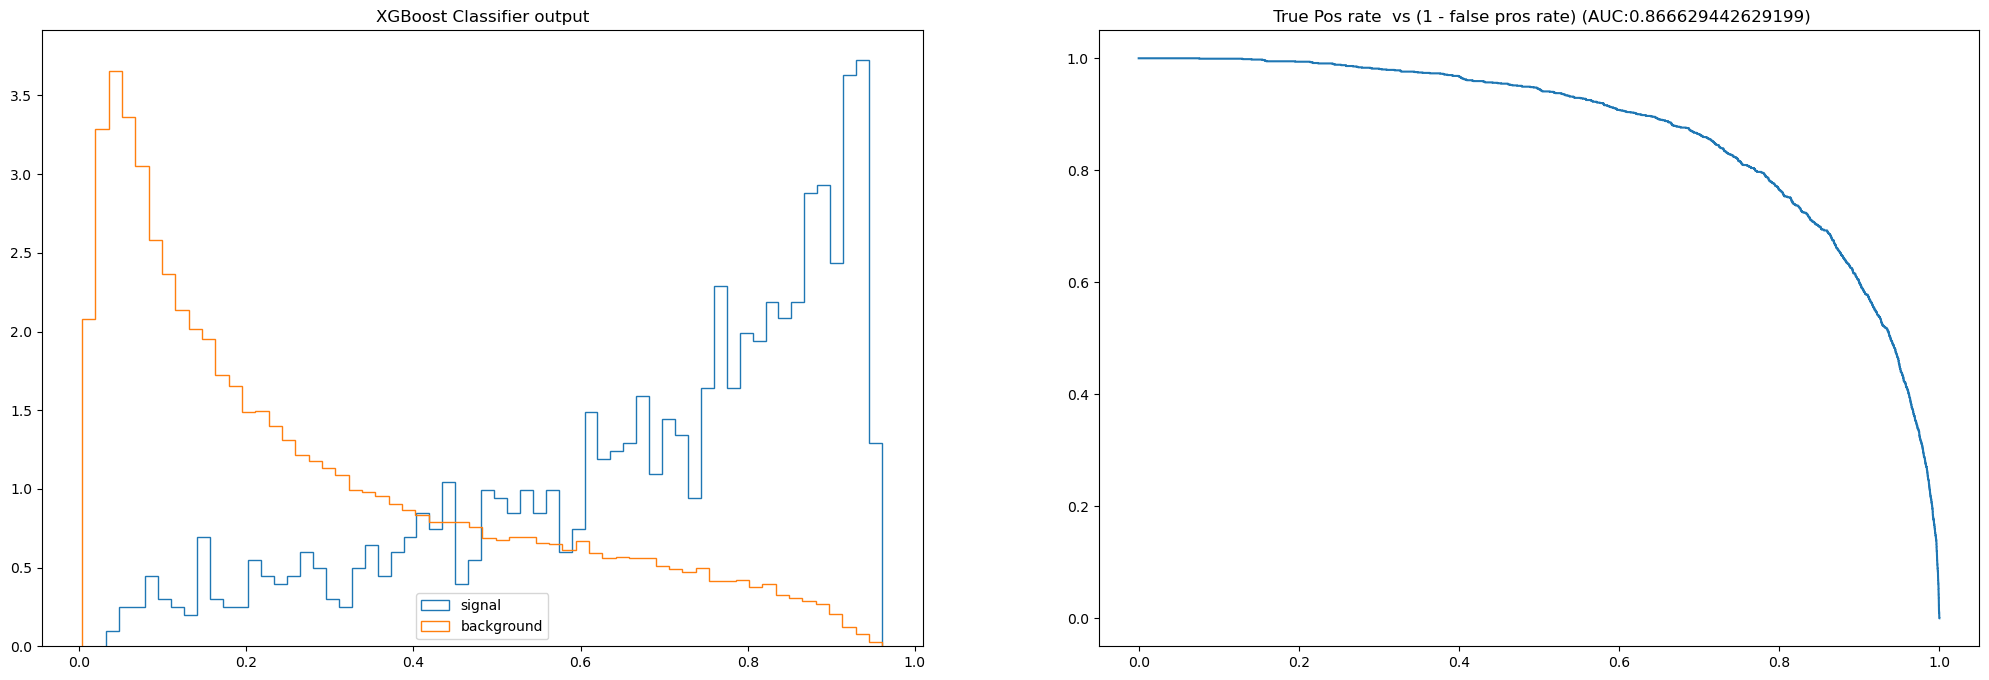

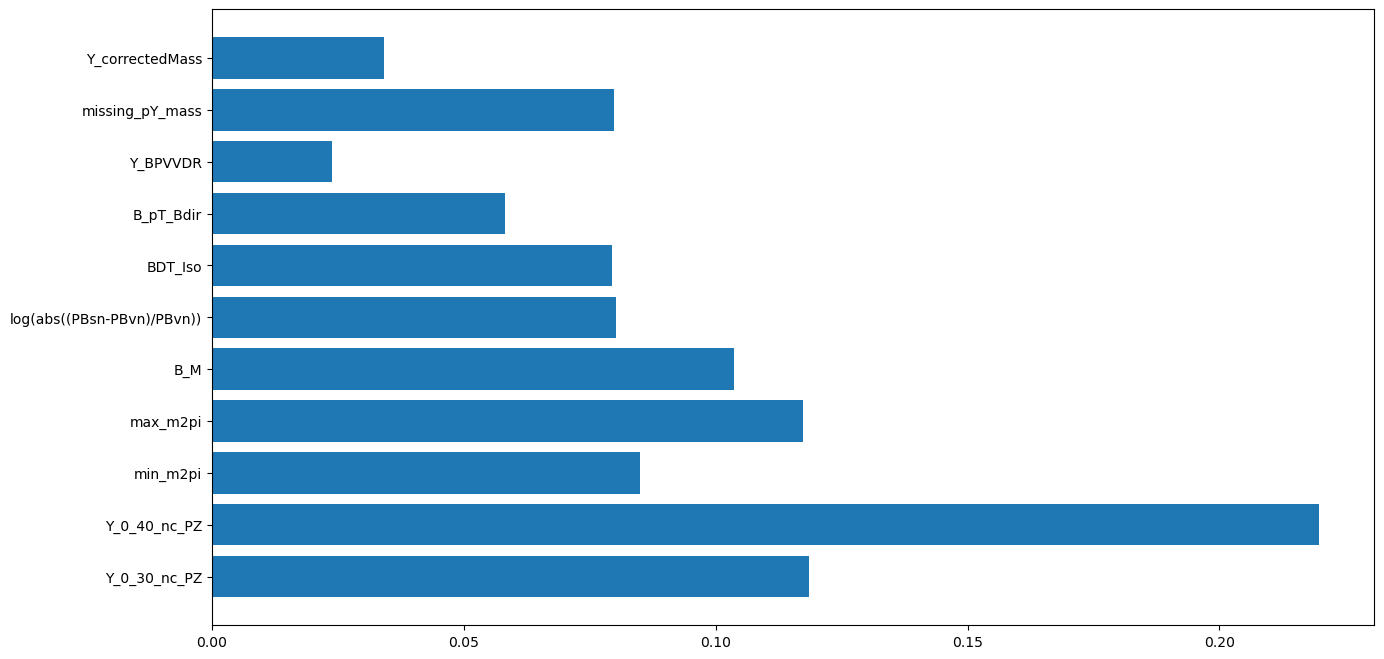

In [54]:
train_columns_8 = [
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "B_M",
    "log(abs((PBsn-PBvn)/PBvn))",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]
model8, auc8 = train_model(train, test, train_columns_8)
aucs_stats["without B_BPVVDR"] = auc8
plt.figure()
plt.barh(model8.feature_names_in_, model8.feature_importances_);

## Summary

<BarContainer object of 8 artists>

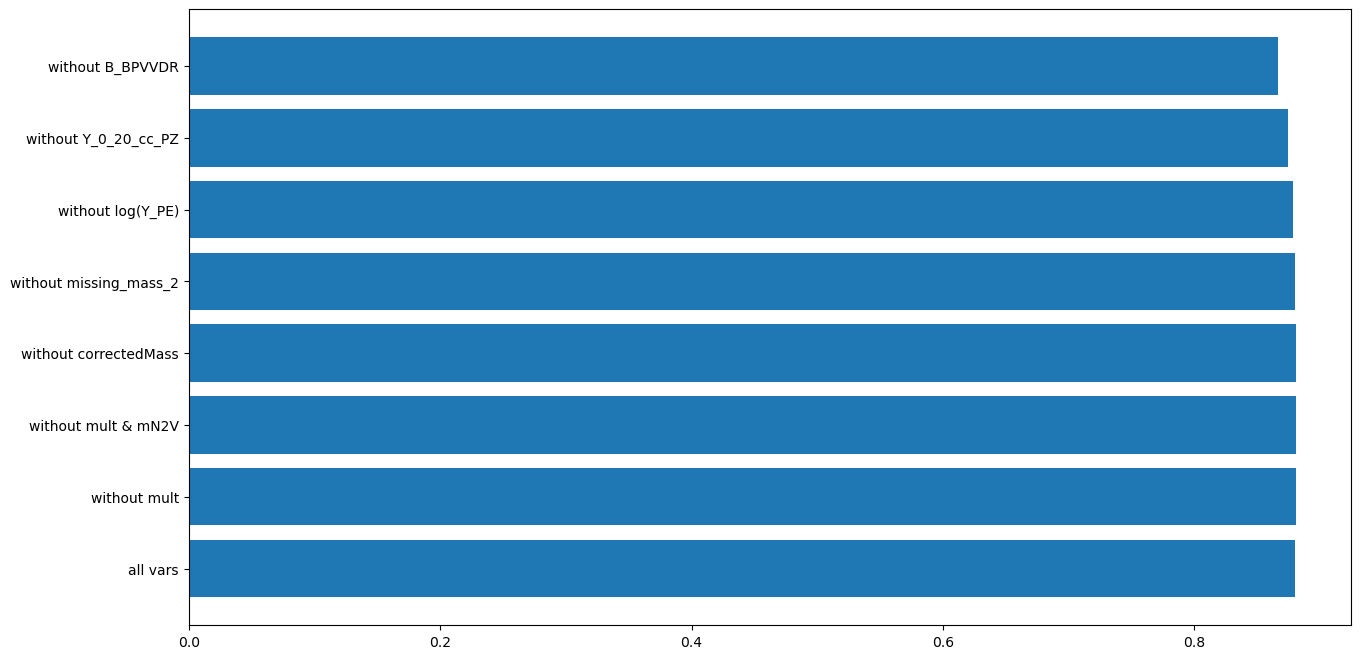

In [55]:
plt.barh(list(aucs_stats.keys()), list(aucs_stats.values()))

In [59]:
pd.DataFrame.from_dict({ k: [v] for k,v in aucs_stats.items() })

,all vars,without mult,without mult & mN2V,without correctedMass,without missing_mass_2,without log(Y_PE),without Y_0_20_cc_PZ,without B_BPVVDR
0,0.88031,0.880643,0.880658,0.880474,0.880319,0.878653,0.874672,0.866629
